<a href="https://colab.research.google.com/github/liscano2/ALBERTO-EPIDEMIOLOGIA/blob/main/albertoepidemiologiajulio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline RAM Magdalena — Parte 2: Análisis Exploratorio de Datos (EDA)

**Entrada:** `base_pretratada_RAM_Magdalena.xlsx` (hoja `datos_aislamientos`, 1590 aislamientos × 58 columnas).
**Objetivo de esta parte:** conocer la estructura, calidad y distribución de los datos antes de construir los análisis del artículo — completitud, distribuciones, y outliers.

> Sube el archivo `base_pretratada_RAM_Magdalena.xlsx` a Colab (panel izquierdo o `files.upload()`) antes de correr la sección 1.

---


In [2]:
## 0. Configuración e importación

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110





In [3]:
from google.colab import files
print("Selecciona base_pretratada_RAM_Magdalena.xlsx:")
archivo_subido = files.upload()
RUTA_BASE = list(archivo_subido.keys())[0]

df_base_pretratada = pd.read_excel(RUTA_BASE, sheet_name="datos_aislamientos")

# Verificación de que se cargó el archivo correcto (no una hoja cruda)
columnas_esperadas = {"anio", "mes", "microorganismo", "servicio", "area_uci", "MDR", "n_testeados"}
faltantes = columnas_esperadas - set(df_base_pretratada.columns)
if faltantes:
    raise ValueError(
        f"El archivo cargado NO es la base pretratada correcta. Faltan columnas: {faltantes}.\n"
        f"Verifica que subiste 'base_pretratada_RAM_Magdalena.xlsx' (no uno de los archivos originales)\n"
        f"y que la hoja se llama 'datos_aislamientos'."
    )

print("✓ Archivo correcto verificado.")
print("Filas:", df_base_pretratada.shape[0], "| Columnas:", df_base_pretratada.shape[1])
df_base_pretratada.head()

Selecciona base_pretratada_RAM_Magdalena.xlsx:


Saving base_pretratada_RAM_Magdalena.xlsx to base_pretratada_RAM_Magdalena.xlsx
✓ Archivo correcto verificado.
Filas: 1590 | Columnas: 58


,num_muestra,id_paciente,anio,mes,fecha,microorganismo,micro_cod,tipo_microorg,servicio,servicio_raw,area_uci,poblacion,tipo_muestra,n_testeados,n_resistentes,n_sensibles,n_intermedios,pct_resistencia,n_clases_resistentes,MDR,CZA,CZT,AMK,AMP,CEP,CZO,FEP,CPT,CAZ,CIP,CLI,SAM,DAP,ERY,ETP,STH,FOS,GEN,GEH,IPM,LNZ,NIT,OXA,PEN,TZP,RIF,TCY,SXT,VAN,LVX,MEM,ATM,CRO,TGC,CAS,FLU,VOR,CTX
0,0265401-HC1,10435109,2023,8,2023-08-29,Acinetobacter baumannii,aba,Gram negativo,Servicio Quirúrgico,s.qx,No UCI,No especificada,Sangre/Hemocultivo,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0215515-OC,1081802952,2023,3,2023-03-21,Acinetobacter baumannii,aba,Gram negativo,Urgencias Adultos,urg ad,No UCI,Adultos,Orina,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0278013-HC1,1081827970,2023,10,2023-10-07,Acinetobacter baumannii,aba,Gram negativo,UCI Adultos,uci ad,UCI,Adultos,Sangre/Hemocultivo,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0272074-MV,1221984903,2023,9,2023-09-19,Acinetobacter baumannii,aba,Gram negativo,Hospitalización Pediátrica,hosped,No UCI,Pediátrica/Neonatal,Sangre/Hemocultivo,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0220298-HC1,230436104116,2023,4,2023-04-06,Acinetobacter baumannii,aba,Gram negativo,UCI Neonatal,ucine,UCI,Pediátrica/Neonatal,Sangre/Hemocultivo,8,1,7,0,12.5,1,No MDR,NaN,NaN,S,NaN,NaN,R,NaN,NaN,S,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,S,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Estructura general

In [4]:
df_base_pretratada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1590 entries, 0 to 1589
Data columns (total 58 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   num_muestra           1590 non-null   object        
 1   id_paciente           1590 non-null   object        
 2   anio                  1590 non-null   int64         
 3   mes                   1590 non-null   int64         
 4   fecha                 1590 non-null   datetime64[ns]
 5   microorganismo        1590 non-null   object        
 6   micro_cod             1590 non-null   object        
 7   tipo_microorg         1590 non-null   object        
 8   servicio              1589 non-null   object        
 9   servicio_raw          1589 non-null   object        
 10  area_uci              1590 non-null   object        
 11  poblacion             1590 non-null   object        
 12  tipo_muestra          1590 non-null   object        
 13  n_testeados       

In [5]:
# Columnas de antibiótico vs metadatos (se usa en toda la Parte 2 y en partes siguientes)
ANTIBIOTICOS = [c for c in df_base_pretratada.columns
                if c.isupper() and 2 <= len(c) <= 4 and c != "MDR"]
METADATOS = [c for c in df_base_pretratada.columns if c not in ANTIBIOTICOS]

print(f"Metadatos ({len(METADATOS)}):", METADATOS)
print(f"\nAntibióticos ({len(ANTIBIOTICOS)}):", ANTIBIOTICOS)

Metadatos (20): ['num_muestra', 'id_paciente', 'anio', 'mes', 'fecha', 'microorganismo', 'micro_cod', 'tipo_microorg', 'servicio', 'servicio_raw', 'area_uci', 'poblacion', 'tipo_muestra', 'n_testeados', 'n_resistentes', 'n_sensibles', 'n_intermedios', 'pct_resistencia', 'n_clases_resistentes', 'MDR']

Antibióticos (38): ['CZA', 'CZT', 'AMK', 'AMP', 'CEP', 'CZO', 'FEP', 'CPT', 'CAZ', 'CIP', 'CLI', 'SAM', 'DAP', 'ERY', 'ETP', 'STH', 'FOS', 'GEN', 'GEH', 'IPM', 'LNZ', 'NIT', 'OXA', 'PEN', 'TZP', 'RIF', 'TCY', 'SXT', 'VAN', 'LVX', 'MEM', 'ATM', 'CRO', 'TGC', 'CAS', 'FLU', 'VOR', 'CTX']


## 3. Completitud y datos faltantes

### 3.1 Faltantes en metadatos

In [6]:
faltantes_meta = df_base_pretratada[METADATOS].isna().sum()
faltantes_meta = faltantes_meta[faltantes_meta > 0].sort_values(ascending=False)
print("Metadatos con valores faltantes:")
print(faltantes_meta if len(faltantes_meta) else "Ninguno")

Metadatos con valores faltantes:
pct_resistencia    70
servicio            1
servicio_raw        1
dtype: int64


### 3.2 Faltantes en antibióticos (= "no testeado", no es un error)

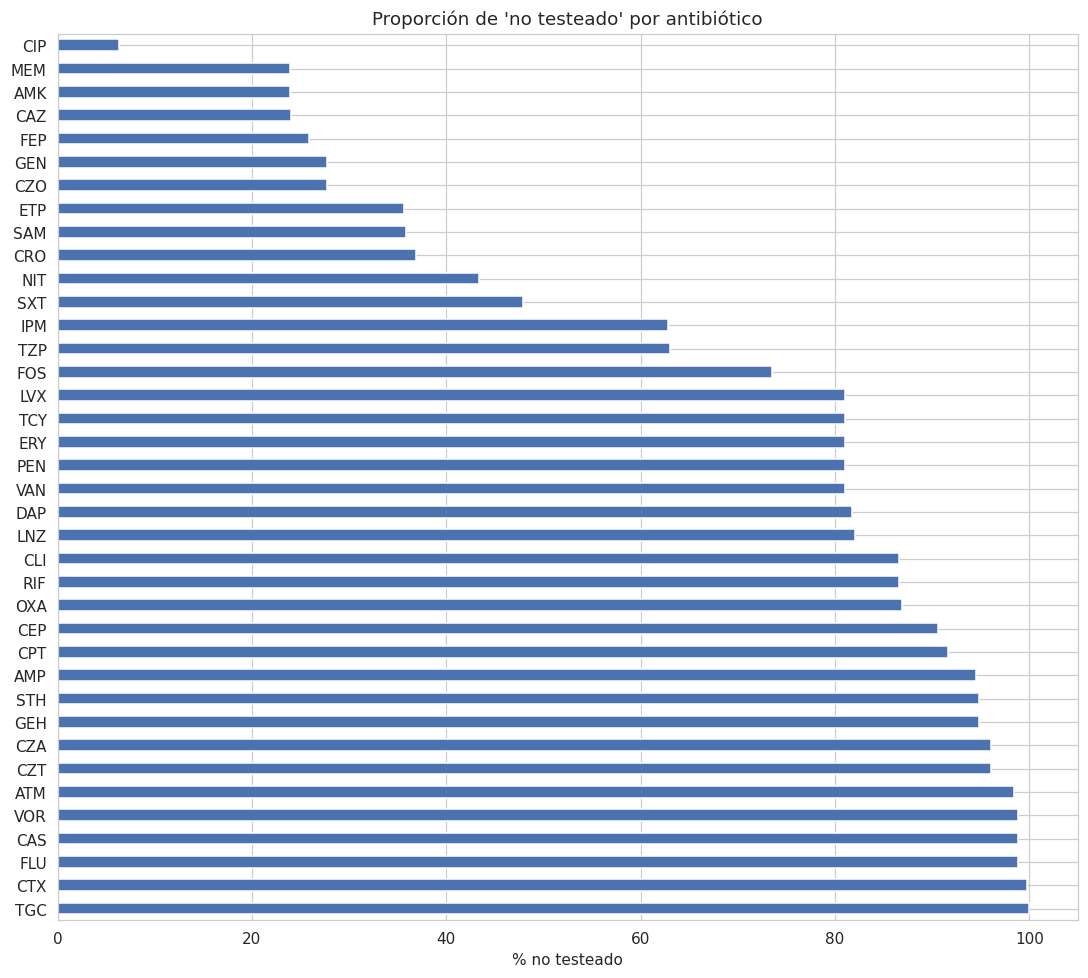

TGC    100.0
CTX     99.7
FLU     98.8
CAS     98.8
VOR     98.8
ATM     98.4
CZT     96.0
CZA     96.0
GEH     94.8
STH     94.8
AMP     94.5
CPT     91.6
CEP     90.6
OXA     86.9
RIF     86.6
CLI     86.6
LNZ     82.1
DAP     81.7
VAN     81.1
PEN     81.1
ERY     81.1
TCY     81.1
LVX     81.1
FOS     73.5
TZP     63.0
IPM     62.8
SXT     47.9
NIT     43.4
CRO     36.9
SAM     35.8
ETP     35.7
CZO     27.7
GEN     27.7
FEP     25.8
CAZ     24.0
AMK     24.0
MEM     24.0
CIP      6.4
dtype: float64


In [52]:
faltantes_ab = df_base_pretratada[ANTIBIOTICOS].isna().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(10, 9))
faltantes_ab.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% no testeado")
ax.set_title("Proporción de 'no testeado' por antibiótico")
plt.tight_layout()
plt.show()

print(faltantes_ab.round(1))

### 3.3 Mapa de calor de completitud (patrón de testeo)

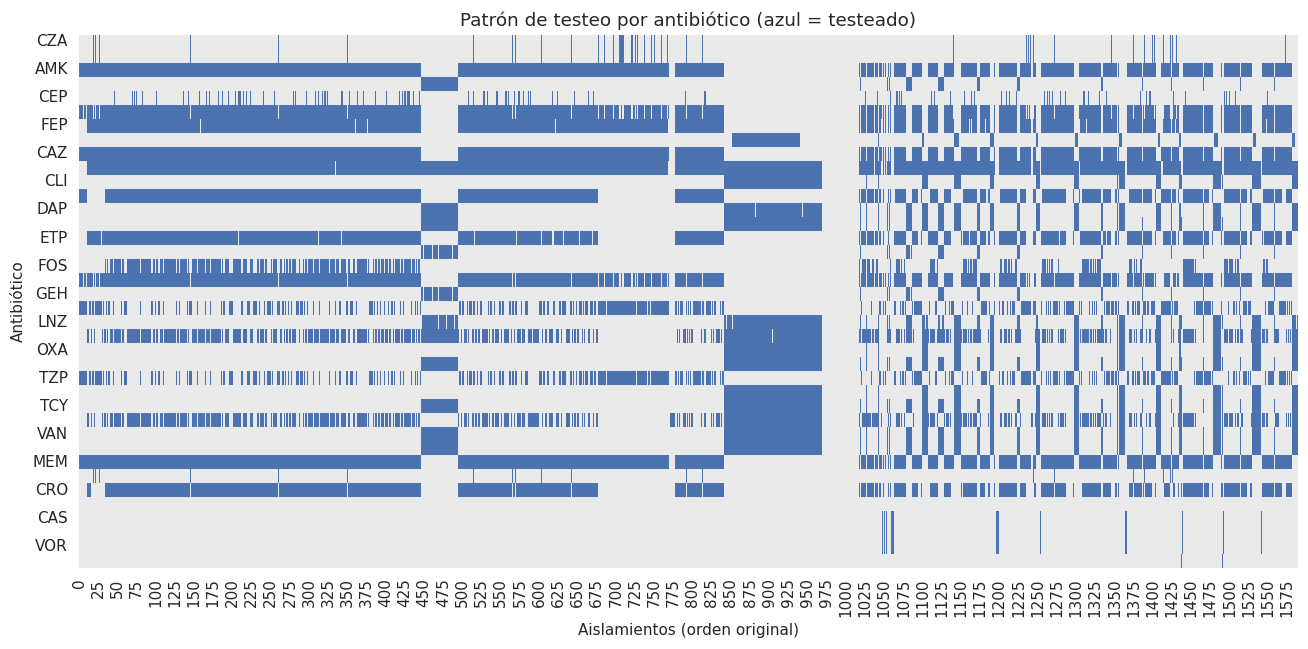

In [53]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_base_pretratada[ANTIBIOTICOS].notna().T, cbar=False,
            cmap=["#EAEAEA", "#4C72B0"], ax=ax)
ax.set_xlabel("Aislamientos (orden original)")
ax.set_ylabel("Antibiótico")
ax.set_title("Patrón de testeo por antibiótico (azul = testeado)")
plt.tight_layout()
plt.show()

## 4. Variables categóricas: distribución

### 4.1 Microorganismos

microorganismo
Escherichia coli                650
Klebsiella pneumoniae           282
Pseudomonas aeruginosa          150
Staphylococcus aureus           137
Proteus mirabilis                94
Enterococcus faecalis            89
Staphylococcus epidermidis       60
Enterobacter cloacae             27
Candida albicans                 19
Staphylococcus saprophyticus     18
Acinetobacter baumannii          15
Stenotrophomonas maltophilia     11
Enterobacter aerogenes           10
Salmonella spp.                   9
Proteus vulgaris                  4
Serratia marcescens               4
Streptococcus pneumoniae          4
Morganella morganii               3
Enterococcus faecium              2
Citrobacter freundii              1
Salmonella Typhi                  1
Name: count, dtype: int64


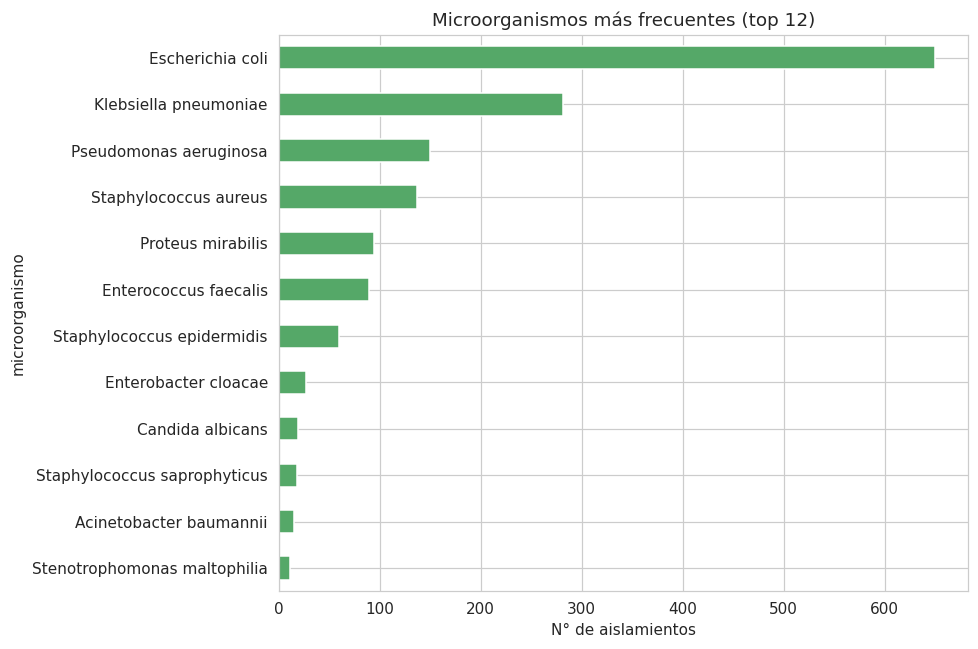

In [56]:
top_micro = df_base_pretratada["microorganismo"].value_counts()
print(top_micro)

fig, ax = plt.subplots(figsize=(9, 6))
top_micro.head(12).plot(kind="barh", ax=ax, color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("N° de aislamientos")
ax.set_title("Microorganismos más frecuentes (top 12)")
plt.tight_layout()
plt.show()

### 4.2 Servicio y área UCI

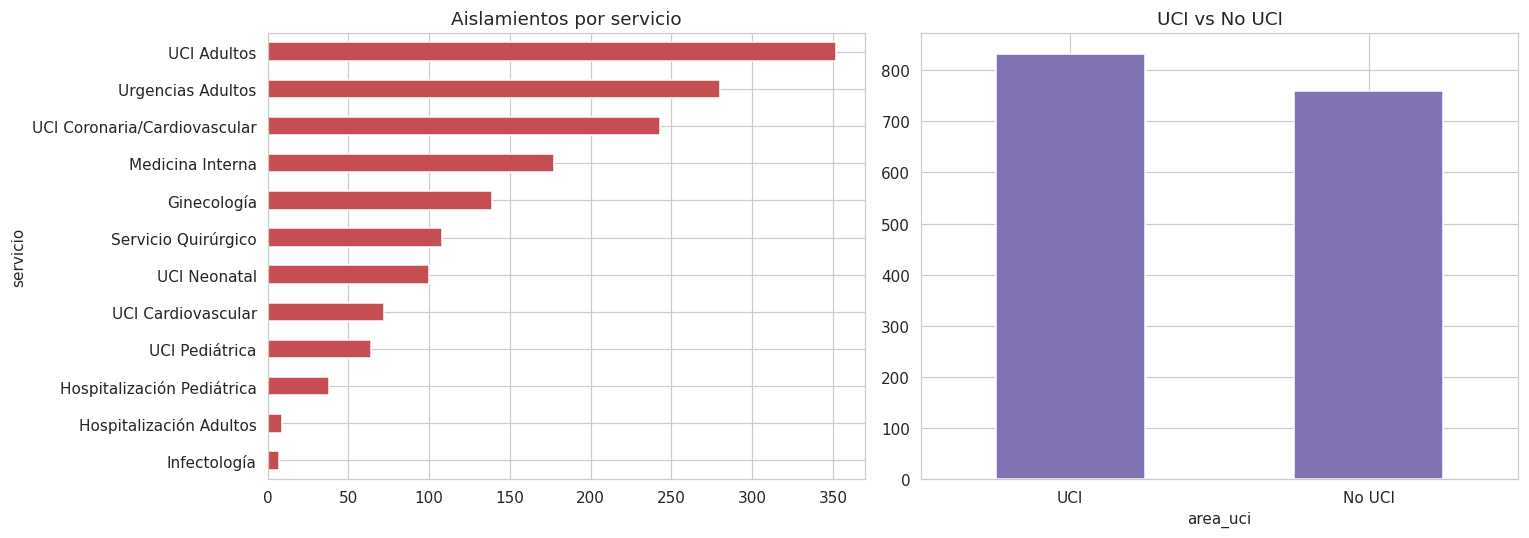

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_base_pretratada["servicio"].value_counts().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].invert_yaxis()
axes[0].set_title("Aislamientos por servicio")

df_base_pretratada["area_uci"].value_counts().plot(kind="bar", ax=axes[1], color="#8172B2")
axes[1].set_title("UCI vs No UCI")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 4.3 Año, tipo de muestra, tipo de microorganismo

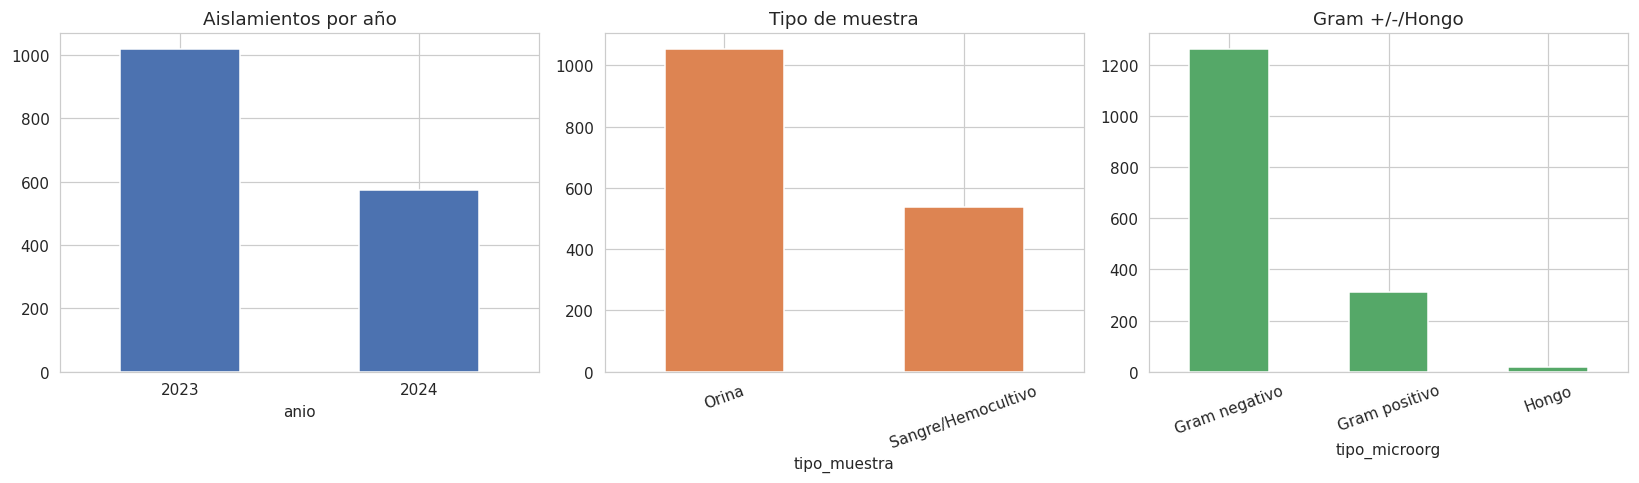

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
df_base_pretratada["anio"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Aislamientos por año"); axes[0].tick_params(axis="x", rotation=0)

df_base_pretratada["tipo_muestra"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Tipo de muestra"); axes[1].tick_params(axis="x", rotation=20)

df_base_pretratada["tipo_microorg"].value_counts().plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("Gram +/-/Hongo"); axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### 4.4 Estacionalidad mensual

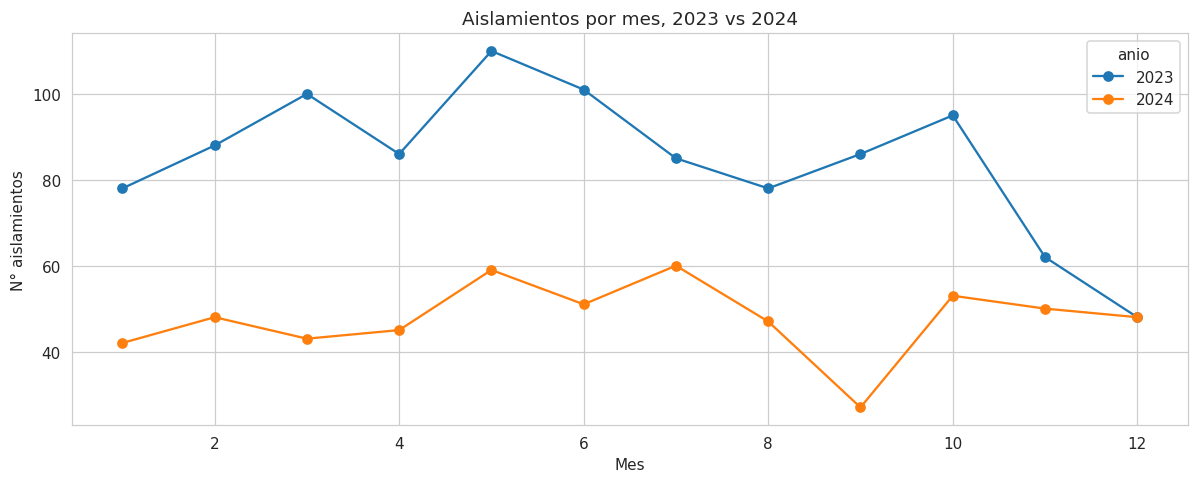

In [59]:
fig, ax = plt.subplots(figsize=(11, 4.5))
pd.crosstab(df_base_pretratada["mes"], df_base_pretratada["anio"]).plot(kind="line", marker="o", ax=ax)
ax.set_xlabel("Mes"); ax.set_ylabel("N° aislamientos")
ax.set_title("Aislamientos por mes, 2023 vs 2024")
plt.tight_layout()
plt.show()

## 5. Variables numéricas derivadas: distribución y outliers

In [60]:
NUM_VARS = ["n_testeados", "n_resistentes", "n_sensibles",
            "n_intermedios", "pct_resistencia", "n_clases_resistentes"]

df_base_pretratada[NUM_VARS].describe().round(1)

,n_testeados,n_resistentes,n_sensibles,n_intermedios,pct_resistencia,n_clases_resistentes
count,1590.0,1590.0,1590.0,1590.0,1520.0,1590.0
mean,11.6,2.3,9.0,0.3,19.6,1.9
std,3.0,2.8,3.5,0.5,22.2,2.1
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,12.0,0.0,7.0,0.0,0.0,0.0
50%,12.0,1.0,10.0,0.0,11.1,1.0
75%,13.0,3.0,12.0,0.0,30.0,3.0
max,18.0,15.0,14.0,3.0,100.0,10.0


### 5.1 Histogramas

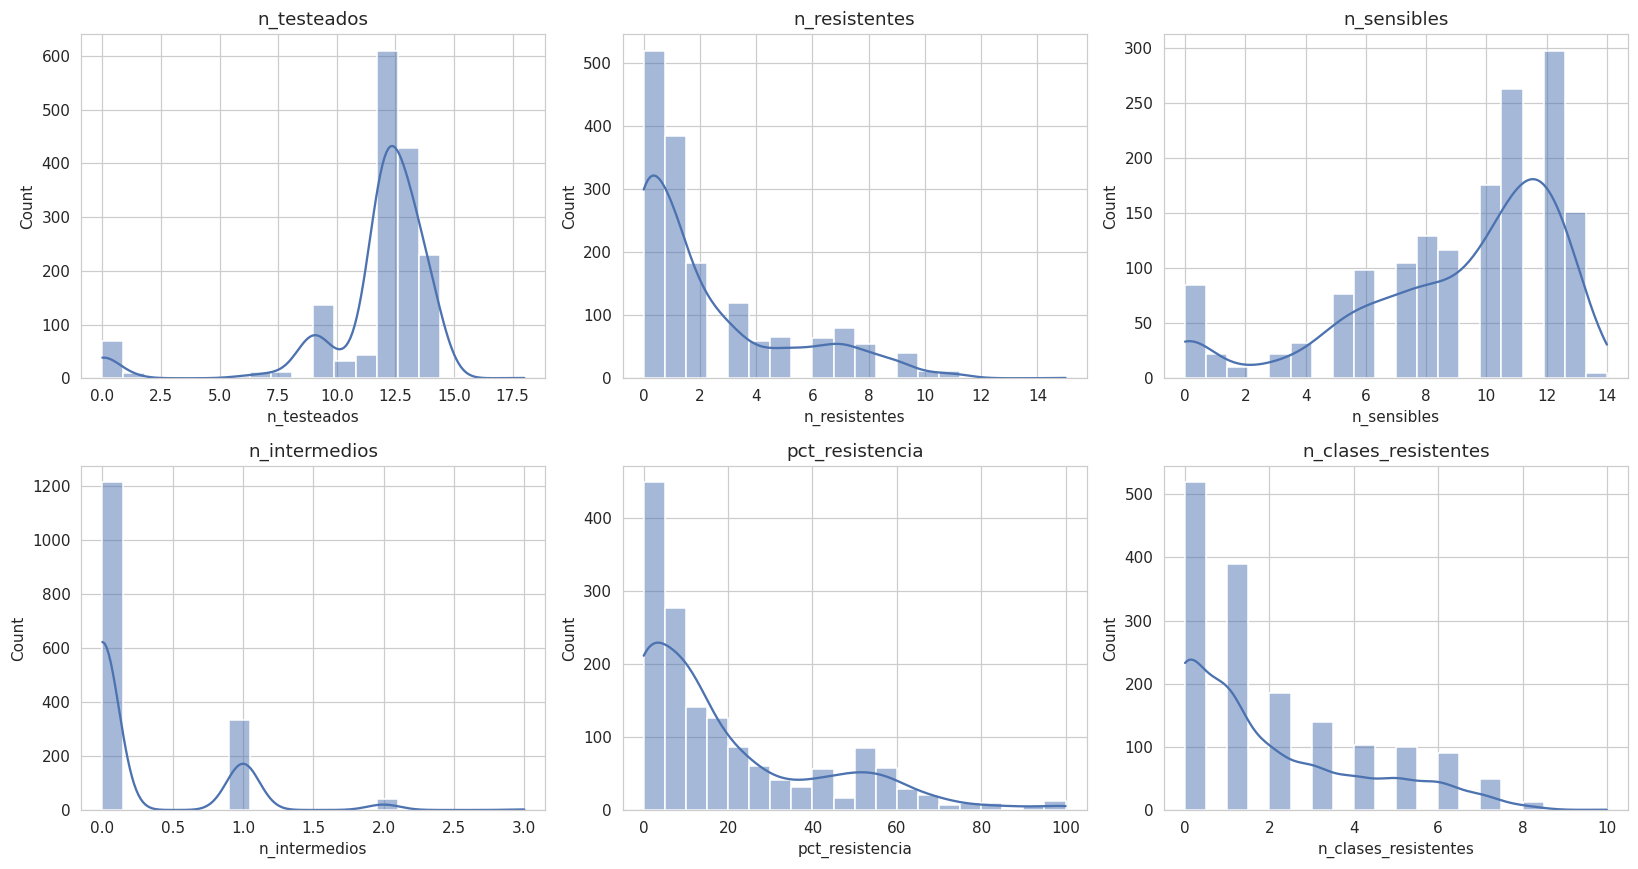

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, NUM_VARS):
    sns.histplot(df_base_pretratada[col].dropna(), bins=20, ax=ax, color="#4C72B0", kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 5.2 Boxplots y detección de outliers (regla IQR)

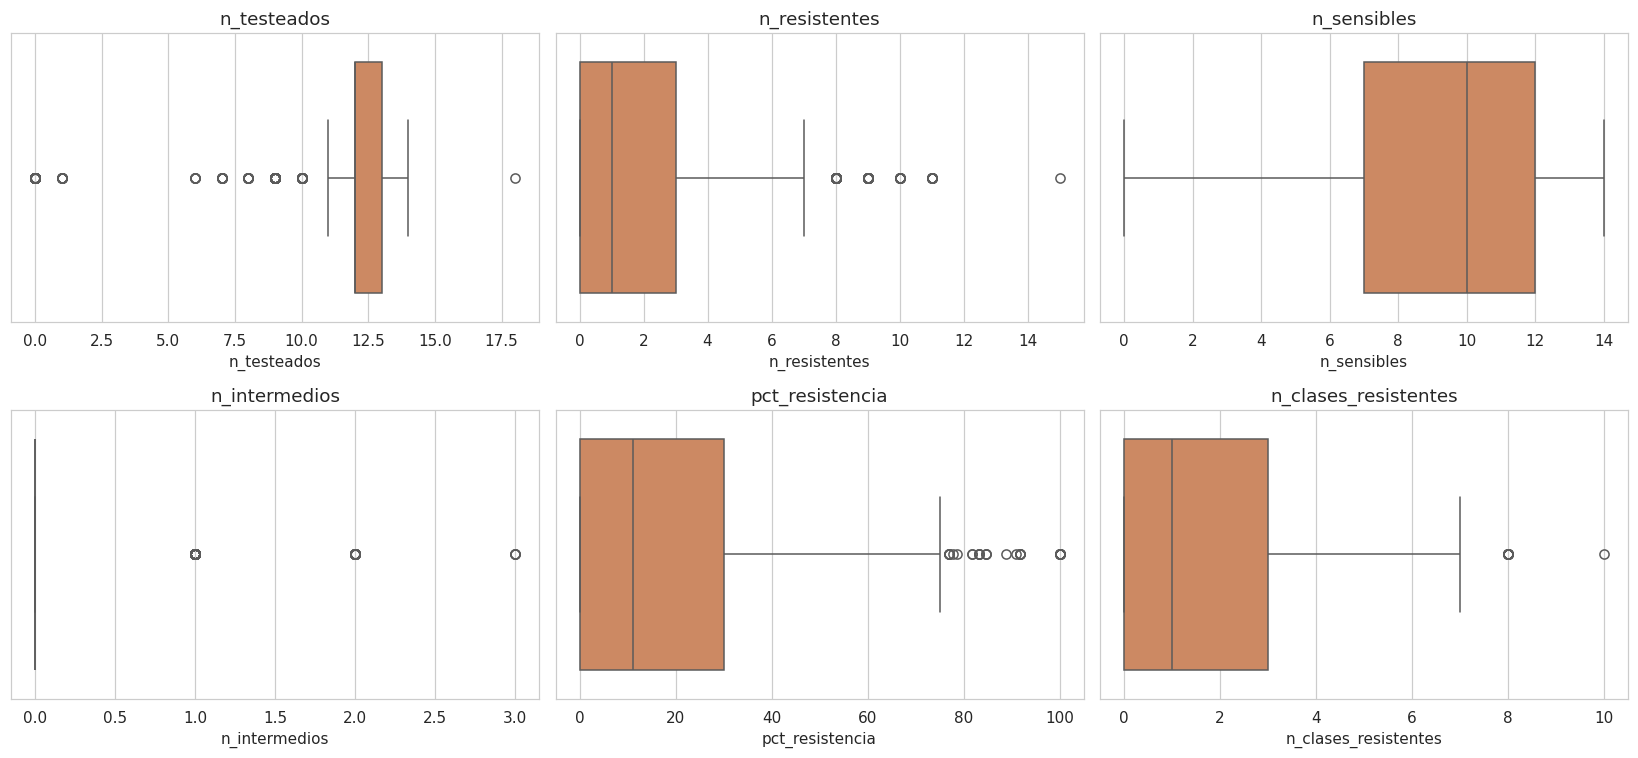

Resumen de outliers por variable (criterio IQR 1.5x):
n_testeados            límites IQR=[10.5, 14.5]  outliers=278 (17.5%)
n_resistentes          límites IQR=[-4.5, 7.5]  outliers=118 (7.4%)
n_sensibles            límites IQR=[-0.5, 19.5]  outliers=0 (0.0%)
n_intermedios          límites IQR=[0.0, 0.0]  outliers=377 (23.7%)
pct_resistencia        límites IQR=[-45.0, 75.0]  outliers=35 (2.3%)
n_clases_resistentes   límites IQR=[-4.5, 7.5]  outliers=14 (0.9%)


In [62]:
def resumen_outliers_iqr(serie, nombre):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = serie[(serie < lo) | (serie > hi)]
    print(f"{nombre:22s} límites IQR=[{lo:.1f}, {hi:.1f}]  outliers={len(outliers)} "
          f"({len(outliers)/serie.notna().sum()*100:.1f}%)")
    return outliers

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, NUM_VARS):
    sns.boxplot(x=df_base_pretratada[col], ax=ax, color="#DD8452")
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Resumen de outliers por variable (criterio IQR 1.5x):")
for col in NUM_VARS:
    resumen_outliers_iqr(df_base_pretratada[col], col)

### 5.3 Inspección de los outliers extremos

In [63]:
q1, q3 = df_base_pretratada["pct_resistencia"].quantile([0.25, 0.75])
iqr = q3 - q1
umbral_alto = q3 + 1.5 * iqr

extremos = df_base_pretratada[df_base_pretratada["pct_resistencia"] >= umbral_alto].sort_values(
    "pct_resistencia", ascending=False)

print(f"Aislamientos con % resistencia >= {umbral_alto:.1f}% (n={len(extremos)}):")
extremos[["num_muestra", "microorganismo", "servicio", "anio",
          "n_testeados", "n_resistentes", "pct_resistencia", "MDR"]].head(20)

Aislamientos con % resistencia >= 75.0% (n=37):


,num_muestra,microorganismo,servicio,anio,n_testeados,n_resistentes,pct_resistencia,MDR
708,0267902-MV,Pseudomonas aeruginosa,Servicio Quirúrgico,2023,11,11,100.0,MDR
719,0211274-MV,Pseudomonas aeruginosa,Medicina Interna,2023,9,9,100.0,MDR
725,0271047-HC1,Pseudomonas aeruginosa,UCI Adultos,2023,9,9,100.0,MDR
718,0239692-HC3,Pseudomonas aeruginosa,UCI Adultos,2023,9,9,100.0,MDR
713,0226658-HC1,Pseudomonas aeruginosa,Medicina Interna,2023,9,9,100.0,MDR
1346,0370612-OC,Pseudomonas aeruginosa,Medicina Interna,2024,9,9,100.0,MDR
1140,0325683-HC1,Pseudomonas aeruginosa,UCI Adultos,2024,9,9,100.0,MDR
1573,0421198-HC1,Pseudomonas aeruginosa,UCI Adultos,2024,11,11,100.0,MDR
1400,0372491-OC,Pseudomonas aeruginosa,UCI Adultos,2024,11,11,100.0,MDR
767,0261818-OC,Pseudomonas aeruginosa,UCI Coronaria/Cardiovascular,2023,9,9,100.0,MDR


### 5.4 Relación n_testeados vs n_resistentes (¿el % de resistencia depende de cuánto se testeó?)

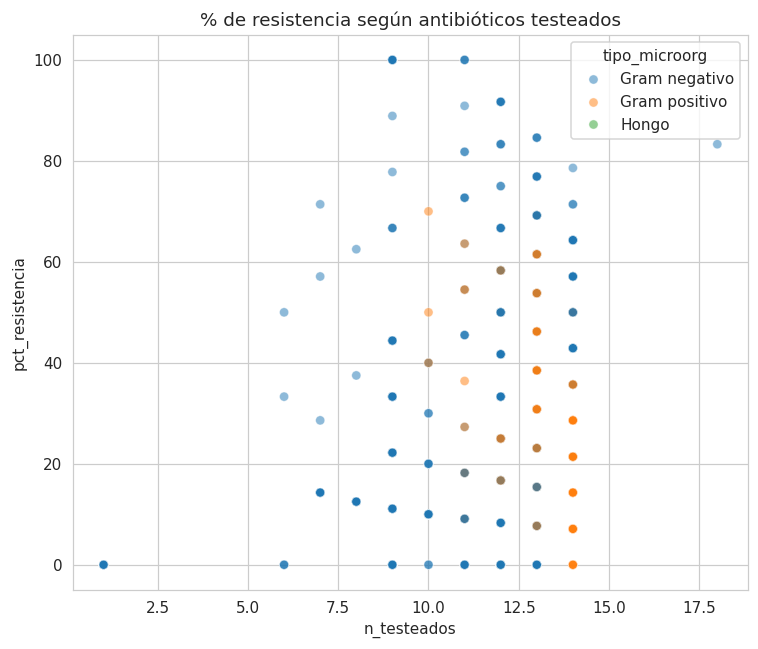

In [64]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=df_base_pretratada, x="n_testeados", y="pct_resistencia",
                 hue="tipo_microorg", alpha=0.5, ax=ax)
ax.set_title("% de resistencia según antibióticos testeados")
plt.tight_layout()
plt.show()

## 6. Distribución de MDR (fenotipo clave del análisis)

Distribución MDR (incluye 'No evaluable'):
MDR
No MDR          1015
MDR              495
No evaluable      61
Name: count, dtype: int64

% MDR entre aislamientos evaluables:
MDR
No MDR    67.2
MDR       32.8
Name: proportion, dtype: float64


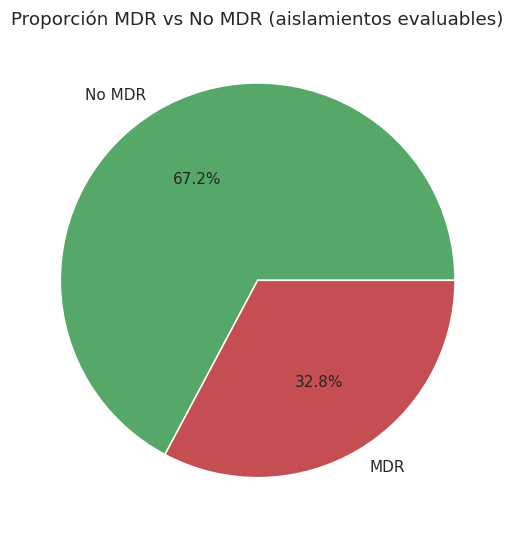

In [65]:
# Excluir hongos (MDR no aplica) y "No evaluable" para el % real
df_bact = df_base_pretratada[df_base_pretratada["tipo_microorg"] != "Hongo"].copy()

print("Distribución MDR (incluye 'No evaluable'):")
print(df_bact["MDR"].value_counts())

print("\n% MDR entre aislamientos evaluables:")
evaluables = df_bact[df_bact["MDR"] != "No evaluable"]
print((evaluables["MDR"].value_counts(normalize=True) * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 5))
evaluables["MDR"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax,
                                       colors=["#55A868", "#C44E52"])
ax.set_ylabel("")
ax.set_title("Proporción MDR vs No MDR (aislamientos evaluables)")
plt.tight_layout()
plt.show()

### 6.1 MDR por microorganismo (top especies)

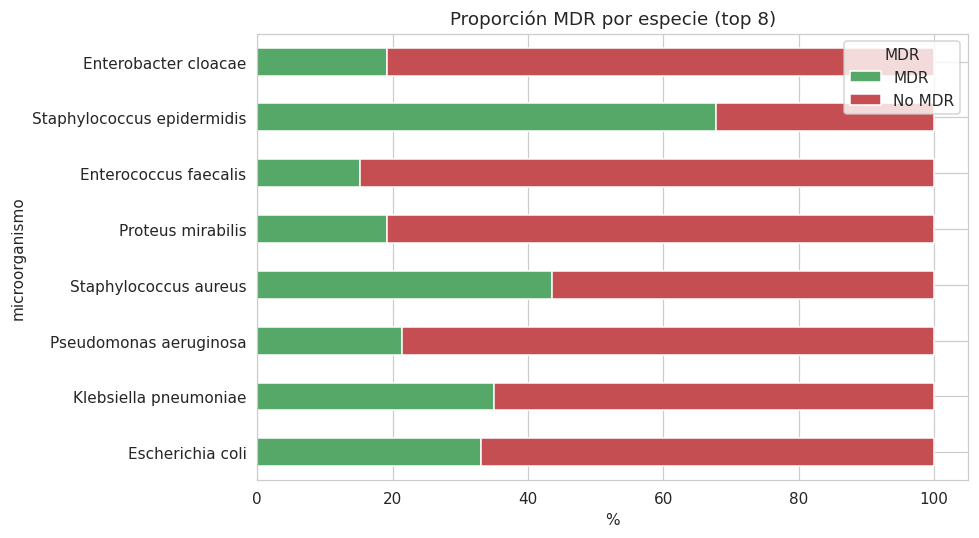

MDR,MDR,No MDR
microorganismo,,
Escherichia coli,33.1,66.9
Klebsiella pneumoniae,35.0,65.0
Pseudomonas aeruginosa,21.4,78.6
Staphylococcus aureus,43.6,56.4
Proteus mirabilis,19.1,80.9
Enterococcus faecalis,15.1,84.9
Staphylococcus epidermidis,67.8,32.2
Enterobacter cloacae,19.2,80.8


In [66]:
top8 = df_bact["microorganismo"].value_counts().head(8).index
sub = evaluables[evaluables["microorganismo"].isin(top8)]

tab_mdr = pd.crosstab(sub["microorganismo"], sub["MDR"], normalize="index") * 100
tab_mdr = tab_mdr.reindex(top8)

fig, ax = plt.subplots(figsize=(9, 5))
tab_mdr.plot(kind="barh", stacked=True, ax=ax, color=["#55A868", "#C44E52"])
ax.set_xlabel("%")
ax.set_title("Proporción MDR por especie (top 8)")
plt.tight_layout()
plt.show()

tab_mdr.round(1)

### 6.2 MDR por área (UCI vs No UCI)

MDR        MDR  No MDR
area_uci              
No UCI    30.1    69.9
UCI       35.3    64.7


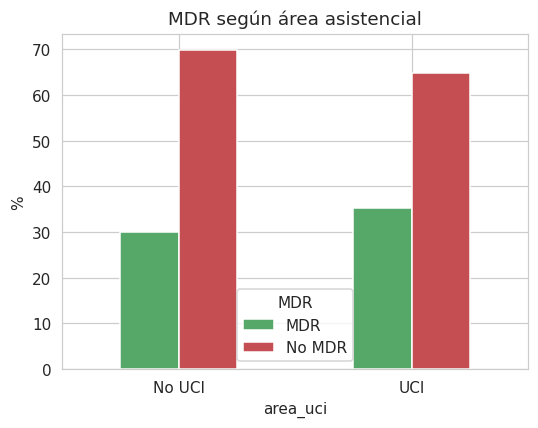

In [67]:
tab_uci = pd.crosstab(evaluables["area_uci"], evaluables["MDR"], normalize="index") * 100
print(tab_uci.round(1))

fig, ax = plt.subplots(figsize=(5, 4))
tab_uci.plot(kind="bar", ax=ax, color=["#55A868", "#C44E52"])
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=0)
ax.set_title("MDR según área asistencial")
plt.tight_layout()
plt.show()

## 7. Matriz de correlación exploratoria (variables numéricas)

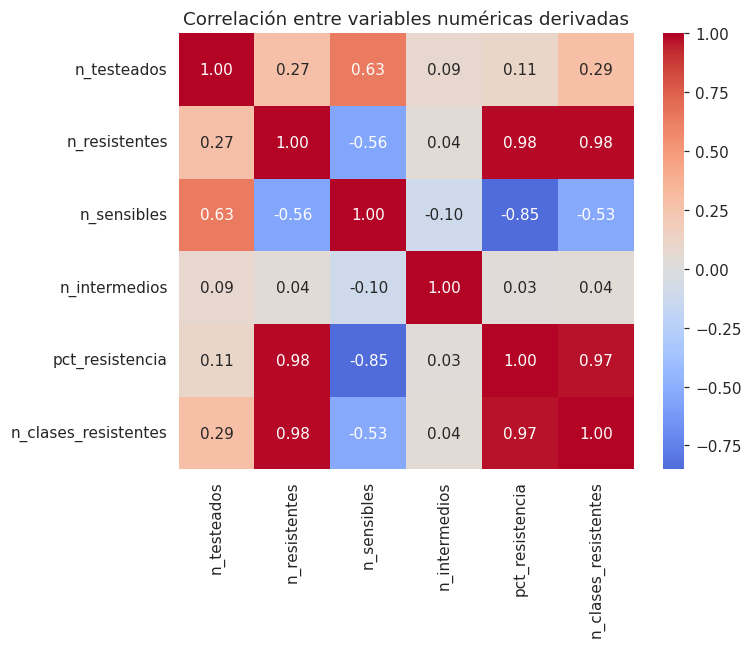

In [68]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df_base_pretratada[NUM_VARS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre variables numéricas derivadas")
plt.tight_layout()
plt.show()

## 8. Resumen ejecutivo del EDA

In [69]:
print("="*65)
print("RESUMEN EDA — base_pretratada_RAM_Magdalena")
print("="*65)
print(f"Aislamientos totales        : {len(df_base_pretratada)}")
print(f"  Bacterias                 : {(df_base_pretratada['tipo_microorg']!='Hongo').sum()}")
print(f"  Hongos (excluir de MDR)   : {(df_base_pretratada['tipo_microorg']=='Hongo').sum()}")
print(f"Antibióticos evaluados      : {len(ANTIBIOTICOS)}")
print(f"Microorganismos distintos   : {df_base_pretratada['microorganismo'].nunique()}")
print(f"Servicios distintos         : {df_base_pretratada['servicio'].nunique()}")
print(f"% MDR (evaluables)          : "
      f"{(evaluables['MDR']=='MDR').mean()*100:.1f}%")
print(f"Outliers pct_resistencia    : {len(extremos)} "
      f"({len(extremos)/df_base_pretratada['pct_resistencia'].notna().sum()*100:.1f}%)")
print("\n✓ EDA completo. Comparte estos resultados para pasar a la Parte 3:")
print("  tabla sociodemográfica → análisis general → descriptivo-analítico (MDR/co-resistencia).")

RESUMEN EDA — base_pretratada_RAM_Magdalena
Aislamientos totales        : 1590
  Bacterias                 : 1571
  Hongos (excluir de MDR)   : 19
Antibióticos evaluados      : 38
Microorganismos distintos   : 21
Servicios distintos         : 12
% MDR (evaluables)          : 32.8%
Outliers pct_resistencia    : 37 (2.4%)

✓ EDA completo. Comparte estos resultados para pasar a la Parte 3:
  tabla sociodemográfica → análisis general → descriptivo-analítico (MDR/co-resistencia).


# Resultados Pipeline RAM Magdalena — Parte 3, Bloque 1: Tabla de caracterización general (Tabla 1)

Entrada: df_base_pretratada (ya cargado en el EDA) o base_pretratada_RAM_Magdalena.xlsx.
Salida: Tabla 1 del artículo — caracterización de los 1590 aislamientos, global y por año, con prueba de asociación (χ²) entre cada variable y el año. Exportable a Excel.


Este es el primer paso del análisis "de lo general a lo específico". La Tabla 1 describe qué se aisló, dónde y de qué muestra, y prueba si el perfil cambió entre 2023 y 2024.




Nota sobre "sociodemográfico": a nivel de aislamiento no hay edad ni sexo individualizados (solo existen agregados por especie, no unibles fila a fila). Por eso la Tabla 1 caracteriza el aislamiento (microorganismo, Gram, servicio/área, muestra), no al paciente. Esto se declara explícitamente en Métodos y Limitaciones — es honesto y estándar en estudios de vigilancia basados en registros de laboratorio.

## 0. Preparación

In [72]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Si no está en memoria desde el EDA, recárgalo:
# df_base_pretratada = pd.read_excel("base_pretratada_RAM_Magdalena.xlsx", sheet_name="datos_aislamientos")

df = df_base_pretratada.copy()

# Agrupar microorganismos: top 8 + "Otros"
TOP_N = 8
top_especies = df["microorganismo"].value_counts().head(TOP_N).index.tolist()
df["micro_grp"] = df["microorganismo"].where(df["microorganismo"].isin(top_especies), "Otros")

print("Total aislamientos:", len(df))
print("2023:", (df['anio']==2023).sum(), "| 2024:", (df['anio']==2024).sum())

Total aislamientos: 1590
2023: 1017 | 2024: 573


## 1. Función generadora de bloques de la tabla

In [73]:
def bloque_tabla(df, var, etiqueta, orden=None):
    """Genera las filas de un bloque de la Tabla 1 para una variable categórica:
    n(%) total, n(%) por año, y valor p de la asociación con el año (χ²)."""
    filas = []
    total = len(df)
    n23_tot = (df["anio"] == 2023).sum()
    n24_tot = (df["anio"] == 2024).sum()
    cats = orden if orden else df[var].value_counts().index.tolist()

    # Prueba χ² de la variable vs año
    ct = pd.crosstab(df[var], df["anio"])
    try:
        chi2, p, _, _ = chi2_contingency(ct)
        pval = f"{p:.3f}" if p >= 0.001 else "<0.001"
    except Exception:
        pval = "—"

    # Fila de encabezado del bloque (lleva el p-valor)
    filas.append([etiqueta, "", "", "", pval])
    for c in cats:
        sub = df[df[var] == c]
        n = len(sub)
        n23 = (sub["anio"] == 2023).sum()
        n24 = (sub["anio"] == 2024).sum()
        filas.append([
            f"   {c}",
            f"{n} ({n/total*100:.1f})",
            f"{n23} ({n23/n23_tot*100:.1f})",
            f"{n24} ({n24/n24_tot*100:.1f})",
            ""
        ])
    return filas

## 2. Construcción de la Tabla 1

In [74]:
rows = []
rows += bloque_tabla(df, "micro_grp", "Microorganismo", top_especies + ["Otros"])
rows += bloque_tabla(df, "tipo_microorg", "Tipo (tinción de Gram)",
                     ["Gram negativo", "Gram positivo", "Hongo"])
rows += bloque_tabla(df, "area_uci", "Área asistencial", ["UCI", "No UCI"])
rows += bloque_tabla(df, "tipo_muestra", "Tipo de muestra",
                     ["Orina", "Sangre/Hemocultivo"])

tabla1 = pd.DataFrame(rows, columns=[
    "Característica",
    f"Total (n={len(df)})",
    f"2023 (n={(df['anio']==2023).sum()})",
    f"2024 (n={(df['anio']==2024).sum()})",
    "p*"
])

# Mostrar
from IPython.display import display
display(tabla1)
print("\n* Prueba χ² de asociación entre la variable y el año de aislamiento.")

,Característica,Total (n=1590),2023 (n=1017),2024 (n=573),p*
0,Microorganismo,,,,<0.001
1,Escherichia coli,650 (40.9),430 (42.3),220 (38.4),
2,Klebsiella pneumoniae,282 (17.7),190 (18.7),92 (16.1),
3,Pseudomonas aeruginosa,150 (9.4),97 (9.5),53 (9.2),
4,Staphylococcus aureus,137 (8.6),93 (9.1),44 (7.7),
5,Proteus mirabilis,94 (5.9),64 (6.3),30 (5.2),
6,Enterococcus faecalis,89 (5.6),52 (5.1),37 (6.5),
7,Staphylococcus epidermidis,60 (3.8),29 (2.9),31 (5.4),
8,Enterobacter cloacae,27 (1.7),19 (1.9),8 (1.4),
9,Otros,101 (6.4),43 (4.2),58 (10.1),



* Prueba χ² de asociación entre la variable y el año de aislamiento.


## 3. Exportación a Excel con formato

In [75]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

wb = Workbook()
ws = wb.active
ws.title = "Tabla1"

titulo = "Tabla 1. Caracterización de los aislamientos bacterianos (HUJMB, 2023–2024)"
ws["A1"] = titulo
ws["A1"].font = Font(bold=True, size=12, name="Arial")
ws.merge_cells("A1:E1")

# Encabezados
hdr = list(tabla1.columns)
ws.append(hdr)
hdr_fill = PatternFill("solid", fgColor="1F4E78")
for j in range(1, len(hdr)+1):
    c = ws.cell(row=2, column=j)
    c.fill = hdr_fill
    c.font = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# Cuerpo
for _, r in tabla1.iterrows():
    ws.append(r.tolist())

# Formato: negrita en filas de encabezado de bloque (las que tienen p-valor y sin sangría)
for i in range(3, ws.max_row+1):
    etiqueta = ws.cell(row=i, column=1).value
    es_bloque = etiqueta and not etiqueta.startswith("   ")
    for j in range(1, len(hdr)+1):
        cell = ws.cell(row=i, column=j)
        cell.font = Font(name="Arial", size=9, bold=bool(es_bloque))
        if j > 1:
            cell.alignment = Alignment(horizontal="center")

# Nota al pie
nota_row = ws.max_row + 2
ws.cell(row=nota_row, column=1,
        value="* Prueba χ² de asociación entre la variable y el año. "
              "Los aislamientos se caracterizan a nivel de muestra; no se dispone de edad/sexo individuales.")
ws.cell(row=nota_row, column=1).font = Font(italic=True, size=8, name="Arial")

# Anchos
ws.column_dimensions["A"].width = 30
for col in ["B", "C", "D", "E"]:
    ws.column_dimensions[col].width = 16

wb.save("Tabla1_caracterizacion.xlsx")
print("✓ Guardada: Tabla1_caracterizacion.xlsx")

# Descargar en Colab:
from google.colab import files
files.download("Tabla1_caracterizacion.xlsx")

✓ Guardada: Tabla1_caracterizacion.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Lectura de resultados (para redactar la sección de Resultados)

In [76]:
print("HALLAZGOS CLAVE DE LA TABLA 1:")
print("-"*55)
# Composición general
gn = (df["tipo_microorg"]=="Gram negativo").mean()*100
print(f"• Predominio de gramnegativos: {gn:.1f}% de los aislamientos.")
# Especie líder
top1 = df["microorganismo"].value_counts().head(2)
print(f"• {top1.index[0]} fue la especie más frecuente "
      f"({top1.iloc[0]} aisl., {top1.iloc[0]/len(df)*100:.1f}%), "
      f"seguida de {top1.index[1]} ({top1.iloc[1]/len(df)*100:.1f}%).")
# Cambio interanual en Gram
ct = pd.crosstab(df["tipo_microorg"], df["anio"])
_, p_gram, _, _ = chi2_contingency(ct)
print(f"• La distribución por Gram cambió entre años (p={'<0.001' if p_gram<0.001 else f'{p_gram:.3f}'}); "
      f"nótese que los 19 hongos (Candida) aparecen solo en 2024.")
# Estabilidad de área y muestra
for v, nombre in [("area_uci","área asistencial"), ("tipo_muestra","tipo de muestra")]:
    _, p, _, _ = chi2_contingency(pd.crosstab(df[v], df["anio"]))
    estable = "sin cambios significativos" if p>=0.05 else "con cambios"
    print(f"• Distribución por {nombre}: {estable} entre años (p={p:.3f}).")

HALLAZGOS CLAVE DE LA TABLA 1:
-------------------------------------------------------
• Predominio de gramnegativos: 79.3% de los aislamientos.
• Escherichia coli fue la especie más frecuente (650 aisl., 40.9%), seguida de Klebsiella pneumoniae (17.7%).
• La distribución por Gram cambió entre años (p=<0.001); nótese que los 19 hongos (Candida) aparecen solo en 2024.
• Distribución por área asistencial: sin cambios significativos entre años (p=0.404).
• Distribución por tipo de muestra: sin cambios significativos entre años (p=0.107).


# Pipeline RAM Magdalena — Parte 3, Bloque 2: Figura 1 compuesta (panorama descriptivo)

**Entrada:** `df_base_pretratada`.
**Salida:** Figura 1 multipanel (A/B/C/D), nativa y en alta resolución (300 dpi), lista para el manuscrito. Se guarda en PNG (para Word) y PDF/SVG vectorial (para el envío a revista).

**Diseño de la figura** — cuatro paneles que responden a "qué se aisló, dónde y cuándo":
- **A** — Microorganismos más frecuentes (top 12)
- **B** — Distribución por servicio hospitalario
- **C** — Tinción de Gram y tipo de muestra
- **D** — Estacionalidad mensual, 2023 vs 2024


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = df_base_pretratada.copy()

# Paleta sobria y consistente (evita colores estridentes; diferencia por panel)
COL_MICRO = "#2C6E8F"   # azul petróleo
COL_SERV  = "#3C8DAD"   # azul medio
COL_GRAM  = "#6B8E23"   # verde oliva
COL_MUES  = "#C1666B"   # terracota apagado
COL_2023  = "#4A7B9D"
COL_2024  = "#D08C34"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
})

## 1. Construcción de la figura compuesta

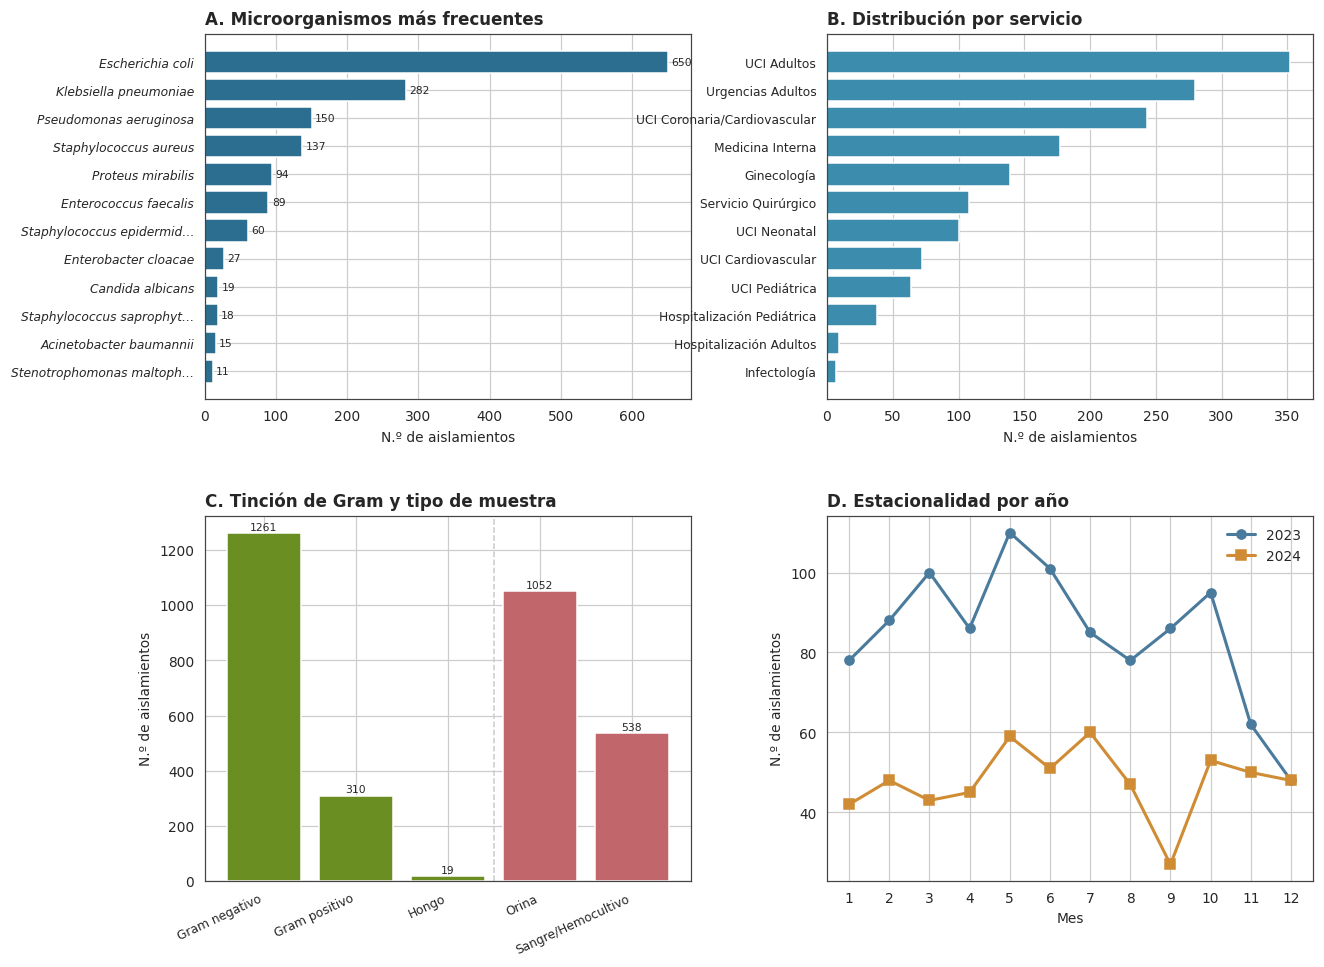

In [80]:
fig = plt.figure(figsize=(13, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.32, wspace=0.28)

# ---------- Panel A: Microorganismos (top 12) ----------
axA = fig.add_subplot(gs[0, 0])
top = df["microorganismo"].value_counts().head(12)[::-1]
axA.barh(range(len(top)), top.values, color=COL_MICRO)
axA.set_yticks(range(len(top)))
axA.set_yticklabels([t if len(t) < 26 else t[:24] + "…" for t in top.index],
                    fontsize=8, fontstyle="italic")
axA.set_xlabel("N.º de aislamientos")
axA.set_title("A. Microorganismos más frecuentes", loc="left")
for i, v in enumerate(top.values):
    axA.text(v + 5, i, str(v), va="center", fontsize=7)

# ---------- Panel B: Servicios ----------
axB = fig.add_subplot(gs[0, 1])
serv = df["servicio"].value_counts()[::-1]
axB.barh(range(len(serv)), serv.values, color=COL_SERV)
axB.set_yticks(range(len(serv)))
axB.set_yticklabels(serv.index, fontsize=8)
axB.set_xlabel("N.º de aislamientos")
axB.set_title("B. Distribución por servicio", loc="left")

# ---------- Panel C: Gram + tipo de muestra ----------
axC = fig.add_subplot(gs[1, 0])
gram = df["tipo_microorg"].value_counts().reindex(["Gram negativo", "Gram positivo", "Hongo"])
muestra = df["tipo_muestra"].value_counts()
cats = list(gram.index) + list(muestra.index)
vals = list(gram.values) + list(muestra.values)
colors = [COL_GRAM]*len(gram) + [COL_MUES]*len(muestra)
bars = axC.bar(range(len(cats)), vals, color=colors)
axC.set_xticks(range(len(cats)))
axC.set_xticklabels(cats, rotation=25, ha="right", fontsize=8)
axC.set_ylabel("N.º de aislamientos")
axC.set_title("C. Tinción de Gram y tipo de muestra", loc="left")
axC.axvline(len(gram) - 0.5, color="#cccccc", ls="--", lw=1)   # separador visual
for b, v in zip(bars, vals):
    axC.text(b.get_x() + b.get_width()/2, v + 10, str(v), ha="center", fontsize=7)

# ---------- Panel D: Estacionalidad ----------
axD = fig.add_subplot(gs[1, 1])
piv = pd.crosstab(df["mes"], df["anio"])
axD.plot(piv.index, piv[2023], marker="o", color=COL_2023, label="2023", lw=2)
axD.plot(piv.index, piv[2024], marker="s", color=COL_2024, label="2024", lw=2)
axD.set_xticks(range(1, 13))
axD.set_xlabel("Mes")
axD.set_ylabel("N.º de aislamientos")
axD.set_title("D. Estacionalidad por año", loc="left")
axD.legend(frameon=False)


plt.show()

## 2. Exportación en alta resolución (PNG + vectorial)

In [81]:
# PNG 300 dpi para Word y revisión
fig.savefig("Figura1_descriptiva.png", dpi=300, bbox_inches="tight")

# Vectorial para el envío final a la revista (escalable sin pérdida)
fig.savefig("Figura1_descriptiva.pdf", bbox_inches="tight")
# fig.savefig("Figura1_descriptiva.svg", bbox_inches="tight")  # alternativa editable

print("✓ Guardadas: Figura1_descriptiva.png (300 dpi) y Figura1_descriptiva.pdf")

# Descargar en Colab
from google.colab import files
files.download("Figura1_descriptiva.png")
files.download("Figura1_descriptiva.pdf")

✓ Guardadas: Figura1_descriptiva.png (300 dpi) y Figura1_descriptiva.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Pie de figura sugerido (para el manuscrito)

**Figura 1.** Caracterización descriptiva de los 1590 aislamientos bacterianos obtenidos en el Hospital Universitario Julio Méndez Barreneche durante 2023–2024. **(A)** Frecuencia de los principales microorganismos aislados. **(B)** Distribución de los aislamientos por servicio hospitalario. **(C)** Composición por tinción de Gram (izquierda) y por tipo de muestra clínica (derecha). **(D)** Número de aislamientos por mes en cada año de estudio. *Candida albicans* se incluye en el panel A por su frecuencia, pero se excluye de los análisis de resistencia bacteriana.

# Pipeline RAM Magdalena — Parte 3, Bloque 3: Perfiles de resistencia por especie (Tabla 2 + Figura 2)

**Entrada:** `df_base_pretratada`.
**Salida:** Tabla 2 (%R con n entre paréntesis, por especie × antibiótico) exportable a Excel, y Figura 2 (mapa de calor de resistencia). Este es el núcleo de la vigilancia RAM: resistencia **antibiótico por antibiótico dentro de cada especie**, que es la forma correcta y comparable de reportarla.

> **Reglas metodológicas aplicadas** (todas validadas contra tus datos):
> - Se excluyen los **hongos** (la resistencia a antibacterianos no aplica).
> - Solo se reporta %R cuando hay **n ≥ 10 aislamientos testeados** para ese par especie–antibiótico; por debajo se marca "—" (una tasa sobre <10 casos es inestable y engañosa).
> - Se **excluye CEP** (cefalotina): en toda la base solo aparece con valor "R" (149 R, 0 S/I), lo que indica **reporte selectivo del laboratorio** (solo se registró cuando resultó resistente), no una resistencia real del 100%. Reportarlo sería un artefacto.
> - Se **conserva LNZ** (linezolid): aparece solo como "S" (285 S, 0 R), pero eso es **biológicamente plausible y clínicamente relevante** (ausencia de resistencia a linezolid en grampositivos). Se reporta como 0.0% con su n.


## 0. Preparación

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = df_base_pretratada.copy()

# Antibióticos (columnas S/I/R)
ANTIBIOTICOS = [c for c in df.columns if c.isupper() and 2 <= len(c) <= 4 and c != "MDR"]

# Excluir hongos para análisis de resistencia bacteriana
dfb = df[df["tipo_microorg"] != "Hongo"].copy()

# Especies con n suficiente (top 8)
ESPECIES = dfb["microorganismo"].value_counts().head(8).index.tolist()

# Antibiótico con reporte degenerado tipo "solo R" -> excluir (sesgo de reporte)
EXCLUIR_AB = ["CEP"]

MIN_N = 10  # umbral mínimo de aislamientos testeados para reportar una tasa
print("Especies analizadas:", ESPECIES)
print("Antibióticos excluidos por sesgo de reporte:", EXCLUIR_AB)

Especies analizadas: ['Escherichia coli', 'Klebsiella pneumoniae', 'Pseudomonas aeruginosa', 'Staphylococcus aureus', 'Proteus mirabilis', 'Enterococcus faecalis', 'Staphylococcus epidermidis', 'Enterobacter cloacae']
Antibióticos excluidos por sesgo de reporte: ['CEP']


## 1. Cálculo de %R por especie × antibiótico

In [83]:
def pct_resistencia(sub, ab, min_n=MIN_N):
    """Devuelve (%R, n) si n>=min_n, si no (None, n)."""
    vals = sub[ab].dropna()
    n = len(vals)
    if n < min_n:
        return None, n
    r = (vals == "R").sum()
    return round(r / n * 100, 1), n

# Antibióticos relevantes: al menos una especie con n>=MIN_N y no excluidos
ab_relevantes = [
    ab for ab in ANTIBIOTICOS
    if ab not in EXCLUIR_AB
    and any((dfb[dfb["microorganismo"] == sp][ab].notna().sum()) >= MIN_N for sp in ESPECIES)
]
print(f"Antibióticos en la Tabla 2: {len(ab_relevantes)}")

Antibióticos en la Tabla 2: 32


## 2. Tabla 2 — formato "%R (n)"

In [84]:
def celda(sub, ab):
    p, n = pct_resistencia(sub, ab)
    return "—" if p is None else f"{p:.1f} ({n})"

# Nombres abreviados de especie para encabezados
def abrev(sp):
    partes = sp.split()
    return f"{partes[0][0]}. {partes[1]}"

filas = []
for ab in ab_relevantes:
    fila = [ab] + [celda(dfb[dfb["microorganismo"] == sp], ab) for sp in ESPECIES]
    filas.append(fila)

tabla2 = pd.DataFrame(filas, columns=["Antibiótico"] + [abrev(sp) for sp in ESPECIES])

from IPython.display import display
display(tabla2)
print("Valores: % de resistencia (n testeados). '—' = n < 10 (no reportable).")

,Antibiótico,E. coli,K. pneumoniae,P. aeruginosa,S. aureus,P. mirabilis,E. faecalis,S. epidermidis,E. cloacae
0,CZA,—,40.0 (10),42.1 (38),—,—,—,—,—
1,CZT,—,40.0 (10),39.5 (38),—,—,—,—,—
2,AMK,0.5 (632),0.0 (274),11.0 (145),—,2.2 (89),—,—,0.0 (26)
3,AMP,—,—,—,—,—,1.2 (86),—,—
4,CZO,30.6 (624),36.1 (266),100.0 (112),—,22.1 (86),—,—,86.4 (22)
5,FEP,24.7 (623),30.9 (272),11.0 (145),—,14.6 (89),—,—,7.7 (26)
6,CPT,—,—,—,0.0 (133),—,—,—,—
7,CAZ,24.7 (631),30.7 (274),18.6 (145),—,14.6 (89),—,—,19.2 (26)
8,CIP,33.8 (631),27.0 (274),15.2 (145),6.0 (133),9.0 (89),4.7 (86),35.6 (59),11.5 (26)
9,CLI,—,—,—,18.8 (133),—,—,44.1 (59),—


Valores: % de resistencia (n testeados). '—' = n < 10 (no reportable).


## 3. Matriz numérica para el mapa de calor

In [85]:
# Matriz de %R (NaN donde n<MIN_N) para graficar
mat = pd.DataFrame(index=ab_relevantes, columns=ESPECIES, dtype=float)
mat_n = pd.DataFrame(index=ab_relevantes, columns=ESPECIES, dtype=float)
for ab in ab_relevantes:
    for sp in ESPECIES:
        p, n = pct_resistencia(dfb[dfb["microorganismo"] == sp], ab)
        mat.loc[ab, sp] = p if p is not None else np.nan
        mat_n.loc[ab, sp] = n

mat.columns = [abrev(sp) for sp in ESPECIES]
mat_n.columns = [abrev(sp) for sp in ESPECIES]

## 4. Figura 2 — Mapa de calor de resistencia

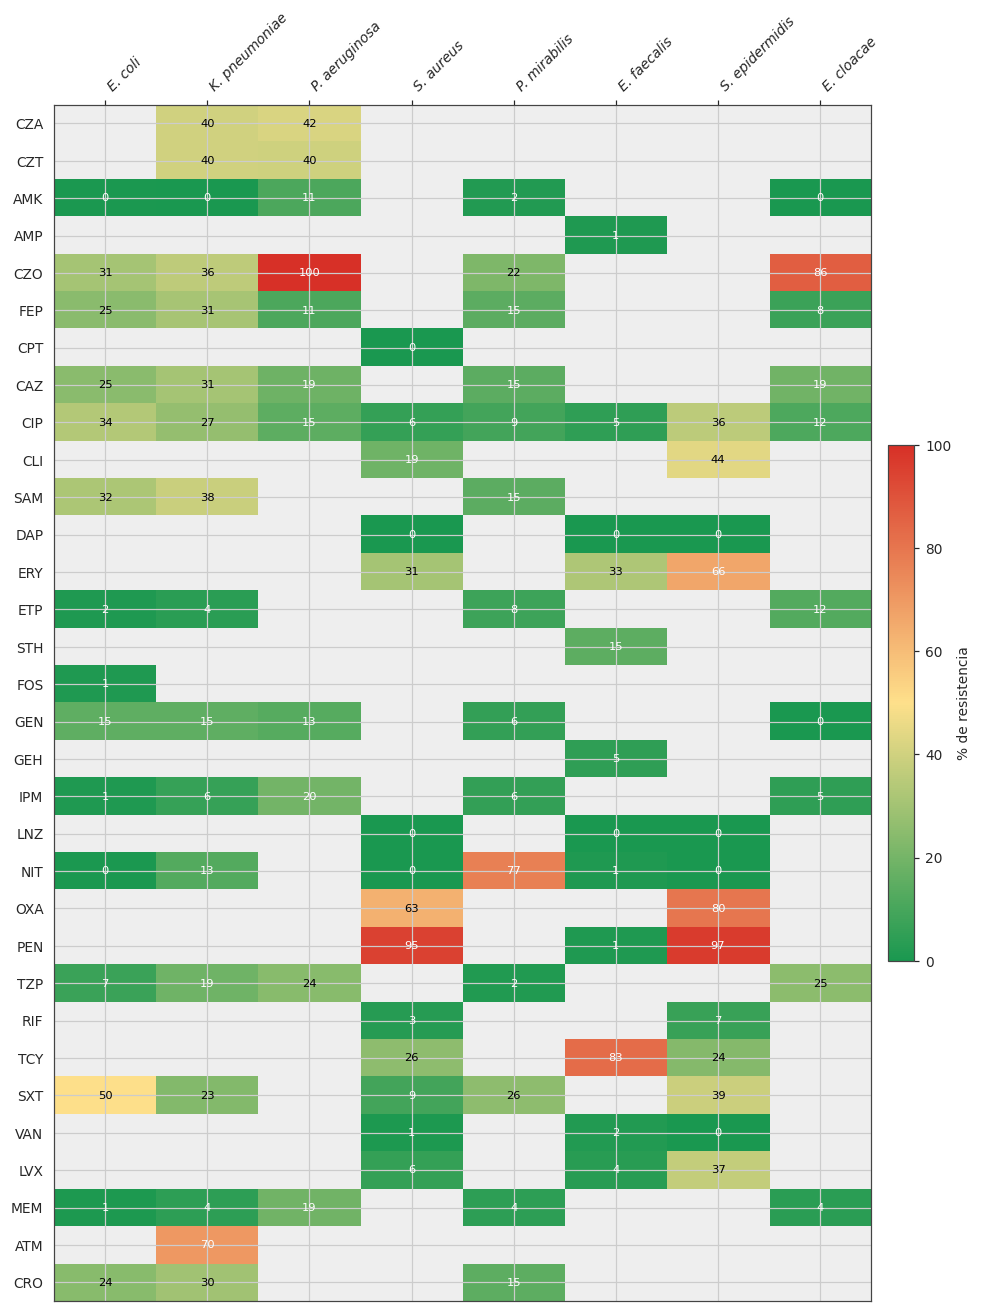

✓ Guardadas: Figura2_heatmap_resistencia.png / .pdf


In [88]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(9, 12))

# Escala de color: verde (bajo) → amarillo → rojo (alto)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "res", ["#1a9850", "#fee08b", "#d73027"])
cmap.set_bad("#eeeeee")   # celdas sin dato (n<10) en gris

im = ax.imshow(mat.values.astype(float), cmap=cmap, vmin=0, vmax=100, aspect="auto")

ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns, rotation=45, ha="left", fontstyle="italic", fontsize=9)
ax.xaxis.tick_top()
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index, fontsize=9)

# Anotar %R en cada celda con dato
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        if not np.isnan(v):
            color = "white" if (v < 20 or v > 65) else "black"
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7.5, color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("% de resistencia", fontsize=9)



plt.tight_layout()
fig.savefig("Figura2_heatmap_resistencia.png", dpi=300, bbox_inches="tight")
fig.savefig("Figura2_heatmap_resistencia.pdf", bbox_inches="tight")
plt.show()
print("✓ Guardadas: Figura2_heatmap_resistencia.png / .pdf")

## 5. Exportación de la Tabla 2 a Excel

In [89]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment

wb = Workbook()
ws = wb.active
ws.title = "Tabla2"
ws["A1"] = "Tabla 2. Resistencia antimicrobiana (%R) por especie y antibiótico, HUJMB 2023–2024"
ws["A1"].font = Font(bold=True, size=12, name="Arial")
ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=len(tabla2.columns))

ws.append(list(tabla2.columns))
hdr_fill = PatternFill("solid", fgColor="1F4E78")
for j in range(1, len(tabla2.columns)+1):
    c = ws.cell(row=2, column=j)
    c.fill = hdr_fill
    c.font = Font(bold=True, color="FFFFFF", name="Arial", size=9, italic=(j > 1))
    c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

for _, r in tabla2.iterrows():
    ws.append(r.tolist())

for i in range(3, ws.max_row+1):
    for j in range(1, len(tabla2.columns)+1):
        cell = ws.cell(row=i, column=j)
        cell.font = Font(name="Arial", size=9, bold=(j == 1))
        if j > 1:
            cell.alignment = Alignment(horizontal="center")

nota = ws.max_row + 2
ws.cell(row=nota, column=1,
        value="Valores: % de resistencia (n de aislamientos testeados). '—' = n < 10 (tasa no reportable). "
              "CEP excluido por reporte selectivo. LNZ sin resistencia detectada.")
ws.cell(row=nota, column=1).font = Font(italic=True, size=8, name="Arial")

ws.column_dimensions["A"].width = 12
for j in range(2, len(tabla2.columns)+1):
    ws.column_dimensions[ws.cell(row=2, column=j).column_letter].width = 14

wb.save("Tabla2_resistencia_especie.xlsx")
print("✓ Guardada: Tabla2_resistencia_especie.xlsx")

from google.colab import files
files.download("Tabla2_resistencia_especie.xlsx")
files.download("Figura2_heatmap_resistencia.png")

✓ Guardada: Tabla2_resistencia_especie.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Pipeline RAM Magdalena — Parte 3, Bloque 4: Prevalencia de MDR (Figura 3 + Tabla 3)

**Entrada:** `df_base_pretratada`.
**Salida:** Tabla 3 (prevalencia de MDR con IC95% por especie, área y año) y Figura 3 (tres paneles con barras de error). Es el puente hacia el eje de novedad: cuantifica la multirresistencia con inferencia estadística, no solo descriptiva.

> **Reglas aplicadas:**
> - Se excluyen hongos y aislamientos con MDR "No evaluable" (<3 antibióticos testeados) del denominador.
> - Intervalos de confianza al 95% por método de **Wilson** (más robusto que el normal para proporciones con n pequeño).
> - Asociación de MDR con área y con año mediante **χ²**.


## 0. Preparación

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import chi2_contingency

df = df_base_pretratada.copy()

# Universo de análisis: bacterias evaluables para MDR
dfb = df[df["tipo_microorg"] != "Hongo"].copy()
ev = dfb[dfb["MDR"] != "No evaluable"].copy()
ev["is_mdr"] = (ev["MDR"] == "MDR").astype(int)

def abrev(sp):
    p = sp.split()
    return f"{p[0][0]}. {p[1]}"

print(f"Aislamientos evaluables para MDR: {len(ev)}")
print(f"MDR global: {ev['is_mdr'].mean()*100:.1f}%")

Aislamientos evaluables para MDR: 1510
MDR global: 32.8%


## 1. Tabla 3 — Prevalencia de MDR con IC95%

In [93]:
def fila_mdr(sub, etiqueta):
    k = sub["is_mdr"].sum()
    n = len(sub)
    if n == 0:
        return [etiqueta, "0", "—"]
    lo, hi = proportion_confint(k, n, method="wilson")
    return [etiqueta, f"{k}/{n}", f"{k/n*100:.1f} ({lo*100:.1f}–{hi*100:.1f})"]

filas = []
# Global
filas.append(fila_mdr(ev, "GLOBAL"))
# Por especie
filas.append(["Por especie", "", ""])
for sp in ev["microorganismo"].value_counts().head(8).index:
    filas.append(fila_mdr(ev[ev["microorganismo"] == sp], "   " + abrev(sp)))
# Por área
filas.append(["Por área asistencial", "", ""])
for a in ["UCI", "No UCI"]:
    filas.append(fila_mdr(ev[ev["area_uci"] == a], "   " + a))
# Por año
filas.append(["Por año", "", ""])
for y in [2023, 2024]:
    filas.append(fila_mdr(ev[ev["anio"] == y], "   " + str(y)))

tabla3 = pd.DataFrame(filas, columns=["Categoría", "MDR/total", "% MDR (IC95%)"])

from IPython.display import display
display(tabla3)

# p-valores de asociación
_, p_area, _, _ = chi2_contingency(pd.crosstab(ev["area_uci"], ev["is_mdr"]))
_, p_anio, _, _ = chi2_contingency(pd.crosstab(ev["anio"], ev["is_mdr"]))
print(f"\nAsociación MDR–área:  p = {p_area:.3f}")
print(f"Asociación MDR–año:   p = {p_anio:.3f}")

,Categoría,MDR/total,% MDR (IC95%)
0,GLOBAL,495/1510,32.8 (30.5–35.2)
1,Por especie,,
2,E. coli,209/632,33.1 (29.5–36.8)
3,K. pneumoniae,96/274,35.0 (29.6–40.9)
4,P. aeruginosa,31/145,21.4 (15.5–28.7)
5,S. aureus,58/133,43.6 (35.5–52.1)
6,P. mirabilis,17/89,19.1 (12.3–28.5)
7,E. faecalis,13/86,15.1 (9.1–24.2)
8,S. epidermidis,40/59,67.8 (55.1–78.3)
9,E. cloacae,5/26,19.2 (8.5–37.9)



Asociación MDR–área:  p = 0.036
Asociación MDR–año:   p = 0.632


## 2. Figura 3 — MDR por especie, área y año

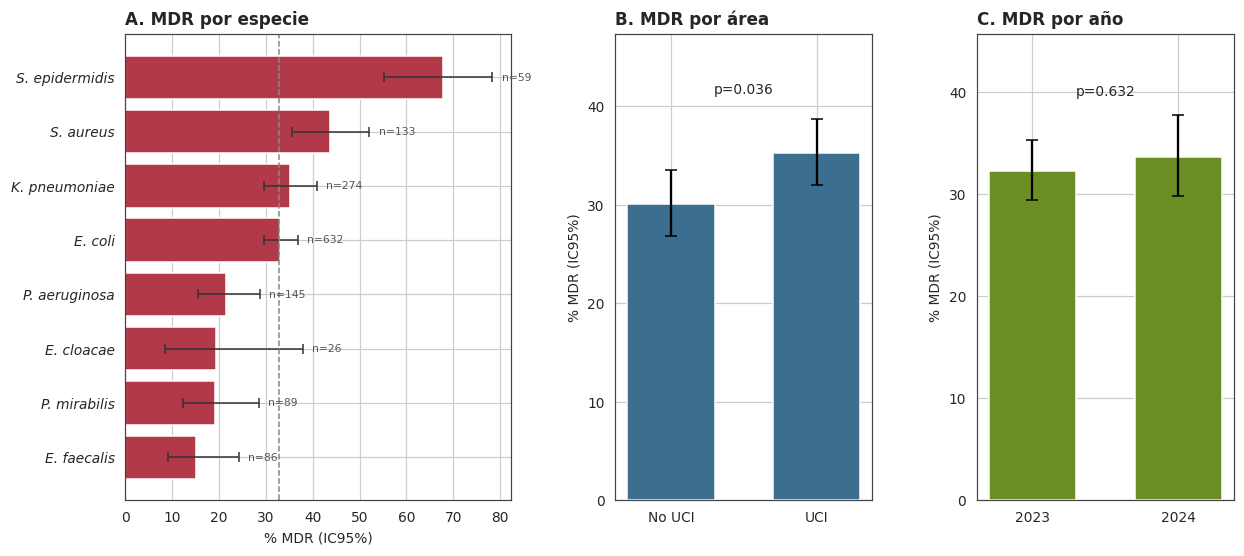

✓ Guardadas: Figura3_MDR.png / .pdf


In [95]:
COL_ESP = "#B23A48"
COL_AREA = "#3C6E8F"
COL_ANIO = "#6B8E23"

fig = plt.figure(figsize=(13, 5.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 1, 1], wspace=0.35)

# ----- Panel A: por especie con IC95 -----
axA = fig.add_subplot(gs[0, 0])
data = []
for sp in ev["microorganismo"].value_counts().head(8).index:
    sub = ev[ev["microorganismo"] == sp]
    k, n = sub["is_mdr"].sum(), len(sub)
    lo, hi = proportion_confint(k, n, method="wilson")
    data.append((abrev(sp), k/n*100, (k/n-lo)*100, (hi-k/n)*100, n))
data.sort(key=lambda x: x[1])
labels = [d[0] for d in data]; vals = [d[1] for d in data]
errlo = [d[2] for d in data]; errhi = [d[3] for d in data]; ns = [d[4] for d in data]
axA.barh(range(len(labels)), vals, xerr=[errlo, errhi], color=COL_ESP,
         error_kw=dict(ecolor="#333", capsize=3, lw=1))
axA.set_yticks(range(len(labels)))
axA.set_yticklabels(labels, fontstyle="italic", fontsize=9)
axA.set_xlabel("% MDR (IC95%)")
axA.set_title("A. MDR por especie", loc="left", fontweight="bold")
for i, (v, n) in enumerate(zip(vals, ns)):
    axA.text(v + errhi[i] + 2, i, f"n={n}", va="center", fontsize=7, color="#555")
axA.axvline(ev["is_mdr"].mean()*100, ls="--", color="#888", lw=1)  # media global

# ----- Panel B: por área -----
axB = fig.add_subplot(gs[0, 1])
areas = ["No UCI", "UCI"]; av, ael, aeh = [], [], []
for a in areas:
    sub = ev[ev["area_uci"] == a]; k, n = sub["is_mdr"].sum(), len(sub)
    lo, hi = proportion_confint(k, n, method="wilson")
    av.append(k/n*100); ael.append((k/n-lo)*100); aeh.append((hi-k/n)*100)
axB.bar(areas, av, yerr=[ael, aeh], color=COL_AREA, capsize=4, width=0.6)
axB.set_ylabel("% MDR (IC95%)")
axB.set_title("B. MDR por área", loc="left", fontweight="bold")
axB.text(0.5, max(av)+6, f"p={p_area:.3f}", ha="center", fontsize=9)
axB.set_ylim(0, max(av)+12)

# ----- Panel C: por año -----
axC = fig.add_subplot(gs[0, 2])
yrs = [2023, 2024]; yv, yel, yeh = [], [], []
for y in yrs:
    sub = ev[ev["anio"] == y]; k, n = sub["is_mdr"].sum(), len(sub)
    lo, hi = proportion_confint(k, n, method="wilson")
    yv.append(k/n*100); yel.append((k/n-lo)*100); yeh.append((hi-k/n)*100)
axC.bar([str(y) for y in yrs], yv, yerr=[yel, yeh], color=COL_ANIO, capsize=4, width=0.6)
axC.set_ylabel("% MDR (IC95%)")
axC.set_title("C. MDR por año", loc="left", fontweight="bold")
axC.text(0.5, max(yv)+6, f"p={p_anio:.3f}", ha="center", fontsize=9)
axC.set_ylim(0, max(yv)+12)

fig.savefig("Figura3_MDR.png", dpi=300, bbox_inches="tight")
fig.savefig("Figura3_MDR.pdf", bbox_inches="tight")
plt.show()
print("✓ Guardadas: Figura3_MDR.png / .pdf")

## 3. Exportar Tabla 3 y descargar

In [96]:
tabla3.to_excel("Tabla3_MDR_prevalencia.xlsx", index=False)

from google.colab import files
files.download("Tabla3_MDR_prevalencia.xlsx")
files.download("Figura3_MDR.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Pipeline RAM Magdalena — Parte 3, Bloque 5: Co-resistencia (Figura 4)

**Entrada:** `df_base_pretratada`.
**Salida:** matriz de co-resistencia (coeficiente φ) y red de co-ocurrencia de resistencias, por especie. **Este es el primer gancho de novedad:** en lugar de reportar resistencia antibiótico por antibiótico, revela qué resistencias **viajan juntas** dentro del mismo aislamiento — información que la vigilancia rutinaria del INS no publica.

> **Por qué esto es novedoso y correcto:**
> - La co-resistencia se analiza **dentro de cada especie**, no en toda la base. Si se mezclaran especies, la correlación capturaría diferencias *entre* especies (una *Pseudomonas* es distinta de un enterococo), no co-ocurrencia real dentro del organismo. Este error es común y lo evitamos.
> - Se usa el coeficiente **φ** (equivalente a Pearson sobre variables binarias R/S), calculado **par a par con los casos que tienen ambos antibióticos testeados** — porque el testeo pareado es incompleto (nunca hay un set completo sin NaN).
> - Solo se incluyen antibióticos con **n ≥ 100 testeados y ≥ 10 resistentes** en esa especie, y cada par requiere **≥ 30 casos pareados**. Por debajo, la correlación es ruido.


## 0. Preparación

In [97]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx

df = df_base_pretratada.copy()
ANTIBIOTICOS = [c for c in df.columns if c.isupper() and 2 <= len(c) <= 4 and c != "MDR"]
dfb = df[df["tipo_microorg"] != "Hongo"].copy()

## 1. Selección de antibióticos aptos por especie

In [98]:
def antibioticos_aptos(sub, min_test=100, min_R=10):
    aptos = []
    for ab in ANTIBIOTICOS:
        v = sub[ab].dropna()
        if len(v) >= min_test and v.nunique() > 1 and (v == "R").sum() >= min_R:
            aptos.append(ab)
    return aptos

# Especie principal (mayor n): E. coli
ESPECIE = "Escherichia coli"
sub = dfb[dfb["microorganismo"] == ESPECIE].copy()
abs_apt = antibioticos_aptos(sub)
print(f"{ESPECIE}: {len(abs_apt)} antibióticos aptos → {abs_apt}")

Escherichia coli: 9 antibióticos aptos → ['CZO', 'FEP', 'CAZ', 'CIP', 'SAM', 'GEN', 'TZP', 'SXT', 'CRO']


## 2. Matriz de co-resistencia φ (par a par)

In [99]:
def matriz_phi(sub, cols, min_pairs=30):
    """Matriz de coeficiente φ entre pares de antibióticos (R=1/S=I=0),
    calculada solo con casos que tienen ambos testeados."""
    m = sub[cols].apply(lambda c: c.map({"R": 1, "S": 0, "I": 0}))
    res = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols, dtype=float)
    npair = pd.DataFrame(0.0, index=cols, columns=cols)
    for a, b in itertools.combinations(cols, 2):
        pair = m[[a, b]].dropna()
        n = len(pair)
        npair.loc[a, b] = npair.loc[b, a] = n
        if n >= min_pairs and pair[a].nunique() > 1 and pair[b].nunique() > 1:
            c = pair[a].corr(pair[b])
        else:
            c = np.nan
        res.loc[a, b] = res.loc[b, a] = c
    return res, npair

corr, npair = matriz_phi(sub, abs_apt)
print("Rango de casos pareados:",
      int(np.nanmin(npair.values[np.triu_indices(len(abs_apt), 1)])), "–",
      int(np.nanmax(npair.values[np.triu_indices(len(abs_apt), 1)])))
display(corr.round(2))

Rango de casos pareados: 0 – 631


,CZO,FEP,CAZ,CIP,SAM,GEN,TZP,SXT,CRO
CZO,1.00,0.86,0.86,0.48,0.38,0.15,0.19,0.26,0.86
FEP,0.86,1.00,1.00,0.58,0.25,0.12,0.11,0.28,1.00
CAZ,0.86,1.00,1.00,0.58,0.25,0.11,0.11,0.28,1.00
CIP,0.48,0.58,0.58,1.00,0.17,0.27,0.17,0.35,0.58
SAM,0.38,0.25,0.25,0.17,1.00,0.23,0.41,0.22,0.25
GEN,0.15,0.12,0.11,0.27,0.23,1.00,0.03,0.21,0.11
TZP,0.19,0.11,0.11,0.17,0.41,0.03,1.00,NaN,0.06
SXT,0.26,0.28,0.28,0.35,0.22,0.21,NaN,1.00,0.27
CRO,0.86,1.00,1.00,0.58,0.25,0.11,0.06,0.27,1.00


## 3. Figura 4 — Matriz de co-resistencia + red

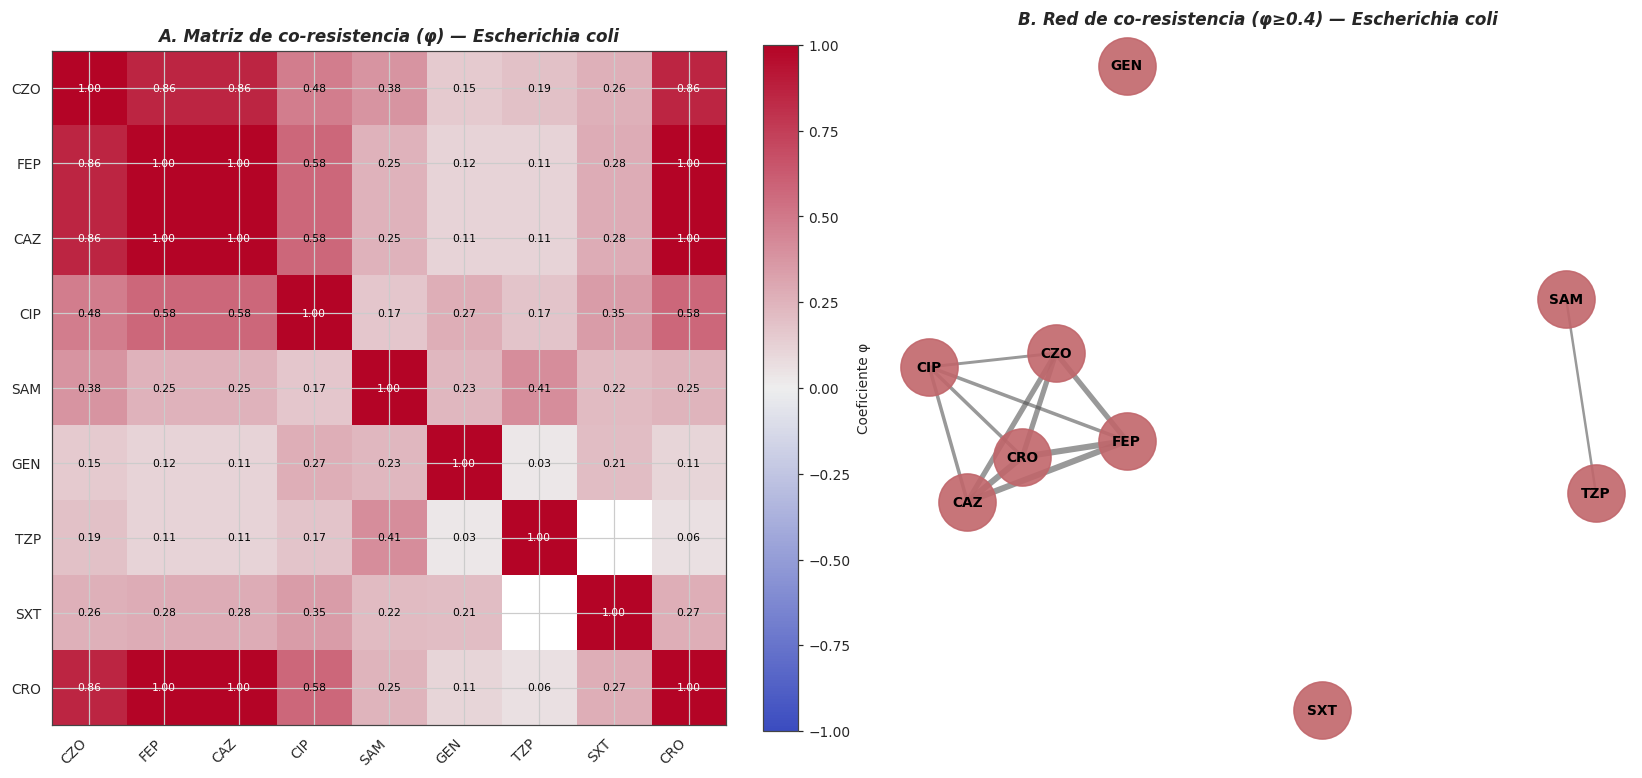

✓ Guardadas: Figura4_coresistencia.png / .pdf


In [100]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# ----- Panel A: heatmap φ -----
cmap = mcolors.LinearSegmentedColormap.from_list("c", ["#3B4CC0", "#EEEEEE", "#B40426"])
im = ax1.imshow(corr.values.astype(float), cmap=cmap, vmin=-1, vmax=1)
ax1.set_xticks(range(len(abs_apt))); ax1.set_xticklabels(abs_apt, rotation=45, ha="right")
ax1.set_yticks(range(len(abs_apt))); ax1.set_yticklabels(abs_apt)
for i in range(len(abs_apt)):
    for j in range(len(abs_apt)):
        v = corr.values[i, j]
        if not np.isnan(v):
            ax1.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                     color="white" if abs(v) > 0.6 else "black")
ax1.set_title(f"A. Matriz de co-resistencia (φ) — {ESPECIE}",
              fontweight="bold", fontstyle="italic")
plt.colorbar(im, ax=ax1, fraction=0.046, label="Coeficiente φ")

# ----- Panel B: red de co-resistencia -----
UMBRAL = 0.4   # solo aristas con co-resistencia moderada-alta
G = nx.Graph()
G.add_nodes_from(abs_apt)
for a, b in itertools.combinations(abs_apt, 2):
    w = corr.loc[a, b]
    if not np.isnan(w) and w >= UMBRAL:
        G.add_edge(a, b, weight=w)

pos = nx.spring_layout(G, seed=42, k=0.9)
nx.draw_networkx_nodes(G, pos, ax=ax2, node_color="#C1666B", node_size=1400, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax2, font_size=9, font_weight="bold")
for u, v, d in G.edges(data=True):
    nx.draw_networkx_edges(G, pos, [(u, v)], ax=ax2,
                           width=d["weight"]*4, alpha=0.6, edge_color="#555")
ax2.set_title(f"B. Red de co-resistencia (φ≥{UMBRAL}) — {ESPECIE}",
              fontweight="bold", fontstyle="italic")
ax2.axis("off")

plt.tight_layout()
fig.savefig("Figura4_coresistencia.png", dpi=300, bbox_inches="tight")
fig.savefig("Figura4_coresistencia.pdf", bbox_inches="tight")
plt.show()
print("✓ Guardadas: Figura4_coresistencia.png / .pdf")

## 4. Extracción de los pares de co-resistencia más fuertes (para la tabla/texto)

In [101]:
pares = []
for a, b in itertools.combinations(abs_apt, 2):
    w = corr.loc[a, b]
    n = npair.loc[a, b]
    if not np.isnan(w):
        pares.append((a, b, round(w, 2), int(n)))
pares_df = pd.DataFrame(pares, columns=["Antibiótico A", "Antibiótico B", "φ", "n pareado"])
pares_df = pares_df.sort_values("φ", ascending=False).reset_index(drop=True)
display(pares_df.head(10))

,Antibiótico A,Antibiótico B,φ,n pareado
0,CAZ,CRO,1.00,623
1,FEP,CRO,1.00,615
2,FEP,CAZ,1.00,623
3,CZO,FEP,0.86,615
4,CZO,CAZ,0.86,623
5,CZO,CRO,0.86,624
6,CAZ,CIP,0.58,630
7,CIP,CRO,0.58,623
8,FEP,CIP,0.58,622
9,CZO,CIP,0.48,623


## 5. Repetir para otras especies con n alto

In [102]:
# Envuelve todo en una función y aplícala a las especies con suficiente n
def coresistencia_especie(especie, min_test=60, min_R=8, umbral=0.4, guardar=True):
    sub = dfb[dfb["microorganismo"] == especie].copy()
    abs_apt = antibioticos_aptos(sub, min_test=min_test, min_R=min_R)
    if len(abs_apt) < 3:
        print(f"{especie}: insuficientes antibióticos aptos ({len(abs_apt)}). Se omite.")
        return None
    corr, npair = matriz_phi(sub, abs_apt)
    # (reutiliza el bloque de figura de la sección 3 cambiando ESPECIE y corr)
    print(f"{especie}: {len(abs_apt)} antibióticos → matriz {corr.shape}")
    return corr, npair, abs_apt

# Ejemplo: Klebsiella pneumoniae y Pseudomonas aeruginosa
for esp in ["Klebsiella pneumoniae", "Pseudomonas aeruginosa", "Staphylococcus aureus"]:
    coresistencia_especie(esp)

Klebsiella pneumoniae: 13 antibióticos → matriz (13, 13)
Pseudomonas aeruginosa: 8 antibióticos → matriz (8, 8)
Staphylococcus aureus: 8 antibióticos → matriz (8, 8)


# Pipeline RAM Magdalena — Parte 3, Bloque 6: Antibiotipos (Figura 5 + Tabla 4)

**Entrada:** `df_base_pretratada`.
**Salida:** clasificación de aislamientos en **antibiotipos** (perfiles latentes de resistencia) mediante clustering jerárquico, con su caracterización clínica y distribución por servicio. **Segundo gancho de novedad:** descubre subgrupos de resistencia dentro de una especie que la vigilancia por antibiótico no revela.

> **Decisiones metodológicas clave (validadas con tus datos):**
> - El clustering necesita una matriz **sin faltantes**. Se define un **núcleo de antibióticos con >90% de testeo** en la especie y se usan los aislamientos con ese núcleo completo (en *E. coli*: 10 antibióticos, 603/650 aislamientos = 93%).
> - Datos binarios R/S → distancia de **Jaccard** con **enlace promedio (average linkage)**, apropiada para presencia/ausencia de resistencia (no euclídea, que asume continuidad).
> - El número de grupos (k) se elige combinando el **coeficiente de silueta** con la **interpretabilidad clínica** — no solo el máximo estadístico. k=3 da grupos limpios y clínicamente nombrables.


## 0. Preparación

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

df = df_base_pretratada.copy()
ANTIBIOTICOS = [c for c in df.columns if c.isupper() and 2 <= len(c) <= 4 and c != "MDR"]
dfb = df[df["tipo_microorg"] != "Hongo"].copy()

ESPECIE = "Escherichia coli"   # cambia para repetir en otras especies con n alto
sub = dfb[dfb["microorganismo"] == ESPECIE].copy()

## 1. Núcleo de antibióticos y matriz binaria

In [104]:
# Antibióticos con >90% de cobertura de testeo y variabilidad
nucleo = [ab for ab in ANTIBIOTICOS
          if sub[ab].notna().mean() > 0.90 and sub[ab].dropna().nunique() > 1]
print(f"{ESPECIE}: núcleo de {len(nucleo)} antibióticos → {nucleo}")

mat = sub[nucleo].apply(lambda c: c.map({"R": 1, "S": 0, "I": 0}))
idx = mat.dropna().index                      # aislamientos con núcleo completo
X = mat.loc[idx].values.astype(bool)
sub_c = sub.loc[idx].copy()
print(f"Aislamientos para clustering: {len(idx)}/{len(sub)} "
      f"({len(idx)/len(sub)*100:.0f}%)")

Escherichia coli: núcleo de 10 antibióticos → ['AMK', 'CZO', 'FEP', 'CAZ', 'CIP', 'SAM', 'ETP', 'GEN', 'MEM', 'CRO']
Aislamientos para clustering: 603/650 (93%)


## 2. Elección del número de antibiotipos (k)

In [105]:
D = pdist(X, metric="jaccard")
Z = linkage(D, method="average")

print("Coeficiente de silueta por k:")
for k in range(2, 7):
    labels = fcluster(Z, k, criterion="maxclust")
    if len(set(labels)) > 1:
        s = silhouette_score(X, labels, metric="jaccard")
        print(f"  k={k}: silhouette={s:.3f}  tamaños={list(np.bincount(labels)[1:])}")

Coeficiente de silueta por k:
  k=2: silhouette=0.631  tamaños=[np.int64(272), np.int64(331)]
  k=3: silhouette=0.677  tamaños=[np.int64(272), np.int64(113), np.int64(218)]
  k=4: silhouette=0.774  tamaños=[np.int64(272), np.int64(113), np.int64(139), np.int64(79)]
  k=5: silhouette=0.780  tamaños=[np.int64(272), np.int64(25), np.int64(88), np.int64(139), np.int64(79)]
  k=6: silhouette=0.817  tamaños=[np.int64(272), np.int64(25), np.int64(52), np.int64(36), np.int64(139), np.int64(79)]


In [106]:
# Se elige k=3 por equilibrio entre silueta y claridad clínica
K = 3
labels = fcluster(Z, K, criterion="maxclust")
sub_c["antibiotipo"] = labels

## 3. Caracterización de cada antibiotipo (Tabla 4)

In [107]:
# Perfil %R de cada grupo + MDR y UCI
filas = []
for c in sorted(set(labels)):
    g = sub_c[sub_c["antibiotipo"] == c]
    perfil_R = {ab: (mat.loc[g.index, ab] == 1).mean()*100 for ab in nucleo}
    filas.append({
        "Antibiotipo": c,
        "n": len(g),
        "%": round(len(g)/len(sub_c)*100, 1),
        "MDR %": round((g["MDR"] == "MDR").mean()*100, 1),
        "UCI %": round((g["area_uci"] == "UCI").mean()*100, 1),
        **{ab: round(perfil_R[ab]) for ab in nucleo}
    })
tabla4 = pd.DataFrame(filas)

# Ordenar por severidad (MDR ascendente) y asignar nombres clínicos
tabla4 = tabla4.sort_values("MDR %").reset_index(drop=True)

# Nombres interpretables (revisar según los perfiles que salgan)
def nombrar(row):
    if row["MDR %"] < 5:
        return "Pansensible"
    if row["CIP"] >= 60 and row[["FEP", "CAZ", "CRO"]].mean() >= 50:
        return "BLEE / fluoroquinolonas"
    if row.get("SAM", 0) >= 60:
        return "Aminopenicilinas / inhibidor"
    return "Intermedio"

tabla4["Fenotipo"] = tabla4.apply(nombrar, axis=1)

from IPython.display import display
display(tabla4)

,Antibiotipo,n,%,MDR %,UCI %,AMK,CZO,FEP,CAZ,CIP,SAM,ETP,GEN,MEM,CRO,Fenotipo
0,1,272,45.1,0.0,43.0,0,0,0,0,0,0,0,0,0,0,Pansensible
1,2,113,18.7,26.5,44.2,0,32,0,0,4,86,0,32,0,0,Aminopenicilinas / inhibidor
2,3,218,36.2,73.4,47.7,0,64,64,64,88,39,3,25,1,64,BLEE / fluoroquinolonas


## 4. Figura 5 — Dendrograma + perfiles de antibiotipo

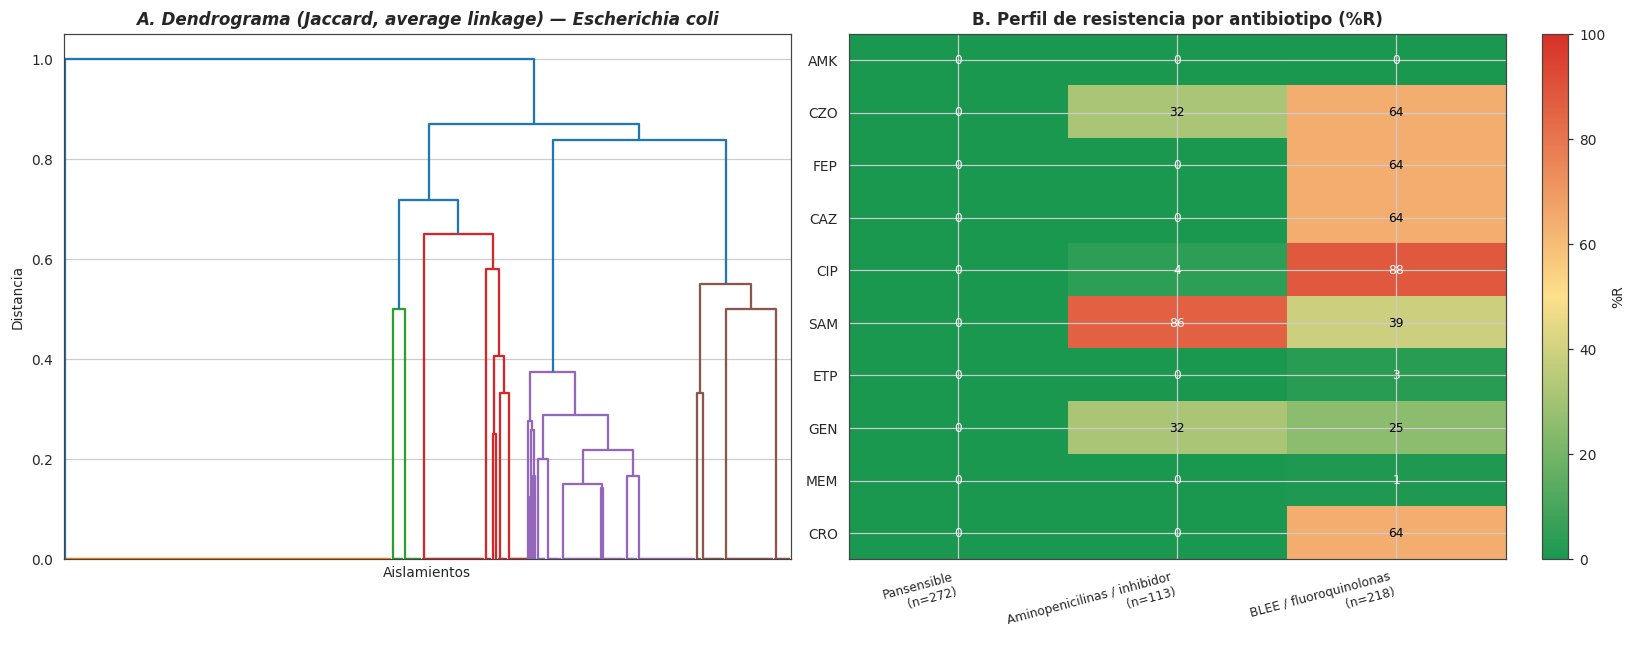

✓ Guardadas: Figura5_antibiotipos.png / .pdf


In [108]:
# Mapa nombre por cluster, en el orden de severidad
orden = tabla4["Antibiotipo"].tolist()
nombres = dict(zip(tabla4["Antibiotipo"], tabla4["Fenotipo"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ----- Panel A: dendrograma -----
dendrogram(Z, ax=axes[0], no_labels=True, color_threshold=0.7*max(Z[:, 2]))
axes[0].set_title(f"A. Dendrograma (Jaccard, average linkage) — {ESPECIE}",
                  fontweight="bold", fontstyle="italic")
axes[0].set_xlabel("Aislamientos")
axes[0].set_ylabel("Distancia")

# ----- Panel B: heatmap de perfiles -----
perf = pd.DataFrame(
    {f"{nombres[c]}\n(n={len(sub_c[sub_c['antibiotipo']==c])})":
     [(mat.loc[sub_c[sub_c["antibiotipo"] == c].index, ab] == 1).mean()*100 for ab in nucleo]
     for c in orden},
    index=nucleo)

cmap = mcolors.LinearSegmentedColormap.from_list("r", ["#1a9850", "#fee08b", "#d73027"])
im = axes[1].imshow(perf.values, cmap=cmap, vmin=0, vmax=100, aspect="auto")
axes[1].set_xticks(range(len(perf.columns)))
axes[1].set_xticklabels(perf.columns, rotation=15, ha="right", fontsize=8)
axes[1].set_yticks(range(len(nucleo)))
axes[1].set_yticklabels(nucleo, fontsize=9)
for i in range(len(nucleo)):
    for j in range(len(perf.columns)):
        v = perf.values[i, j]
        axes[1].text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                     color="white" if (v < 20 or v > 65) else "black")
axes[1].set_title("B. Perfil de resistencia por antibiotipo (%R)", fontweight="bold")
plt.colorbar(im, ax=axes[1], fraction=0.046, label="%R")

plt.tight_layout()
fig.savefig("Figura5_antibiotipos.png", dpi=300, bbox_inches="tight")
fig.savefig("Figura5_antibiotipos.pdf", bbox_inches="tight")
plt.show()
print("✓ Guardadas: Figura5_antibiotipos.png / .pdf")

## 5. ¿Los antibiotipos se concentran en ciertos servicios?

In [109]:
from scipy.stats import chi2_contingency

sub_c["antibiotipo_nom"] = sub_c["antibiotipo"].map(nombres)
ct = pd.crosstab(sub_c["servicio"], sub_c["antibiotipo_nom"])
ct_pct = pd.crosstab(sub_c["servicio"], sub_c["antibiotipo_nom"], normalize="index")*100

print("Distribución de antibiotipos por servicio (%):")
display(ct_pct.round(1))

# Prueba de asociación antibiotipo × área UCI
ct_uci = pd.crosstab(sub_c["area_uci"], sub_c["antibiotipo_nom"])
chi2, p, _, _ = chi2_contingency(ct_uci)
print(f"\nAsociación antibiotipo × área (UCI/No UCI): χ²={chi2:.2f}, p={p:.3f}")

Distribución de antibiotipos por servicio (%):


antibiotipo_nom,Aminopenicilinas / inhibidor,BLEE / fluoroquinolonas,Pansensible
servicio,,,
Ginecología,9.6,34.0,56.4
Hospitalización Adultos,50.0,50.0,0.0
Hospitalización Pediátrica,16.7,16.7,66.7
Infectología,0.0,0.0,100.0
Medicina Interna,17.0,39.6,43.4
Servicio Quirúrgico,17.9,28.6,53.6
UCI Adultos,10.9,46.7,42.4
UCI Cardiovascular,21.7,47.8,30.4
UCI Coronaria/Cardiovascular,19.2,34.2,46.7



Asociación antibiotipo × área (UCI/No UCI): χ²=1.10, p=0.576


## 6. Exportar Tabla 4

In [110]:
tabla4.to_excel("Tabla4_antibiotipos.xlsx", index=False)

from google.colab import files
files.download("Tabla4_antibiotipos.xlsx")
files.download("Figura5_antibiotipos.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [111]:
# Reutiliza las secciones 1-4 cambiando ESPECIE. Recomendado para K. pneumoniae.
# Especies con n suficiente para clustering estable (>=100 aislamientos con núcleo completo):
for esp in ["Klebsiella pneumoniae", "Pseudomonas aeruginosa"]:
    s = dfb[dfb["microorganismo"] == esp]
    nuc = [ab for ab in ANTIBIOTICOS if s[ab].notna().mean() > 0.90 and s[ab].dropna().nunique() > 1]
    m = s[nuc].apply(lambda c: c.map({"R": 1, "S": 0, "I": 0})).dropna()
    print(f"{esp}: núcleo={len(nuc)} antibióticos, {len(m)} aislamientos completos "
          f"→ {'apto' if len(m) >= 100 else 'n insuficiente, tratar con cautela'}")

Klebsiella pneumoniae: núcleo=10 antibióticos, 253 aislamientos completos → apto
Pseudomonas aeruginosa: núcleo=6 antibióticos, 136 aislamientos completos → apto


# Pipeline RAM Magdalena — Parte 3, Bloque 7: Modelo ajustado de MDR (Figura 6 + Tabla 5)

**Entrada:** `df_base_pretratada`.
**Salida:** modelo multivariable de los factores asociados a MDR, con **razones de prevalencia (PR) ajustadas** e IC95%, y forest plot. Es el cierre inferencial: separa qué asociaciones sobreviven al ajuste mutuo de las que eran confusión.

> **Por qué log-binomial y no regresión logística (decisión clave):**
> La MDR es frecuente (**32.8%**, muy por encima del ~10%). Cuando el desenlace es común, el **odds ratio de la logística sobreestima el riesgo** y no se interpreta como razón de prevalencia. El modelo **log-binomial** (GLM binomial con enlace log) estima directamente la **PR**, correcta e interpretable en estudios de prevalencia. Si no convergiera, el respaldo estándar es **Poisson con varianza robusta** (incluido en el código).


## 0. Preparación

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = df_base_pretratada.copy()
dfb = df[df["tipo_microorg"] != "Hongo"].copy()
ev = dfb[dfb["MDR"] != "No evaluable"].copy()
ev["is_mdr"] = (ev["MDR"] == "MDR").astype(int)

print(f"Prevalencia de MDR: {ev['is_mdr'].mean()*100:.1f}% → log-binomial (PR), no logística (OR)")

Prevalencia de MDR: 32.8% → log-binomial (PR), no logística (OR)


## 1. Preparación de variables del modelo

In [8]:
# Restringir a especies con n suficiente (evita categorías con celdas vacías)
TOP = ev["microorganismo"].value_counts().head(6).index.tolist()
m = ev[ev["microorganismo"].isin(TOP)].copy()

# Categóricas con referencia explícita (primer nivel)
m["especie"] = pd.Categorical(m["microorganismo"], categories=TOP)           # ref: E. coli
m["area"]    = pd.Categorical(m["area_uci"], categories=["No UCI", "UCI"])    # ref: No UCI
m["muestra"] = pd.Categorical(m["tipo_muestra"],
                              categories=["Orina", "Sangre/Hemocultivo"])     # ref: Orina
m["anio_c"]  = pd.Categorical(m["anio"].astype(str), categories=["2023", "2024"])  # ref: 2023

print(f"N para el modelo: {len(m)}  (referencias: E. coli, No UCI, Orina, 2023)")

N para el modelo: 1359  (referencias: E. coli, No UCI, Orina, 2023)


## 2. Ajuste del modelo log-binomial (con respaldo Poisson robusto)

In [9]:
formula = "is_mdr ~ especie + area + muestra + anio_c"

try:
    modelo = smf.glm(formula, data=m,
                     family=sm.families.Binomial(link=sm.families.links.Log())).fit()
    metodo = "Log-binomial"
except Exception as e:
    print("Log-binomial no convergió → Poisson robusto. Detalle:", e)
    modelo = smf.glm(formula, data=m, family=sm.families.Poisson()).fit(cov_type="HC0")
    metodo = "Poisson robusto"

print(f"Modelo ajustado: {metodo}")
print(modelo.summary())

Modelo ajustado: Log-binomial
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 is_mdr   No. Observations:                 1359
Model:                            GLM   Df Residuals:                     1350
Model Family:                Binomial   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -823.93
Date:                Sat, 04 Jul 2026   Deviance:                       1647.9
Time:                        19:54:14   Pearson chi2:                 1.36e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.02840
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

## 3. Tabla 5 — Razones de prevalencia ajustadas

In [10]:
res = pd.DataFrame({
    "PR": np.exp(modelo.params),
    "IC95_inf": np.exp(modelo.conf_int()[0]),
    "IC95_sup": np.exp(modelo.conf_int()[1]),
    "p": modelo.pvalues
}).drop("Intercept")

etiquetas = {
    "especie[T.Klebsiella pneumoniae]":  "K. pneumoniae (vs E. coli)",
    "especie[T.Pseudomonas aeruginosa]": "P. aeruginosa (vs E. coli)",
    "especie[T.Staphylococcus aureus]":  "S. aureus (vs E. coli)",
    "especie[T.Proteus mirabilis]":      "P. mirabilis (vs E. coli)",
    "especie[T.Enterococcus faecalis]":  "E. faecalis (vs E. coli)",
    "area[T.UCI]":                        "UCI (vs No UCI)",
    "muestra[T.Sangre/Hemocultivo]":      "Sangre/Hemocultivo (vs Orina)",
    "anio_c[T.2024]":                     "2024 (vs 2023)",
}
res.index = [etiquetas.get(i, i) for i in res.index]

tabla5 = res.copy()
tabla5["PR (IC95%)"] = tabla5.apply(
    lambda r: f"{r['PR']:.2f} ({r['IC95_inf']:.2f}–{r['IC95_sup']:.2f})", axis=1)
tabla5["p"] = tabla5["p"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
tabla5_out = tabla5[["PR (IC95%)", "p"]]

from IPython.display import display
display(tabla5_out)

,PR (IC95%),p
K. pneumoniae (vs E. coli),1.04 (0.85–1.27),0.687
P. aeruginosa (vs E. coli),0.62 (0.44–0.87),0.005
S. aureus (vs E. coli),1.19 (0.90–1.57),0.212
P. mirabilis (vs E. coli),0.56 (0.36–0.88),0.011
E. faecalis (vs E. coli),0.44 (0.26–0.74),0.002
UCI (vs No UCI),1.04 (0.89–1.22),0.584
Sangre/Hemocultivo (vs Orina),1.13 (0.92–1.38),0.259
2024 (vs 2023),1.05 (0.89–1.23),0.574


## 4. Figura 6 — Forest plot

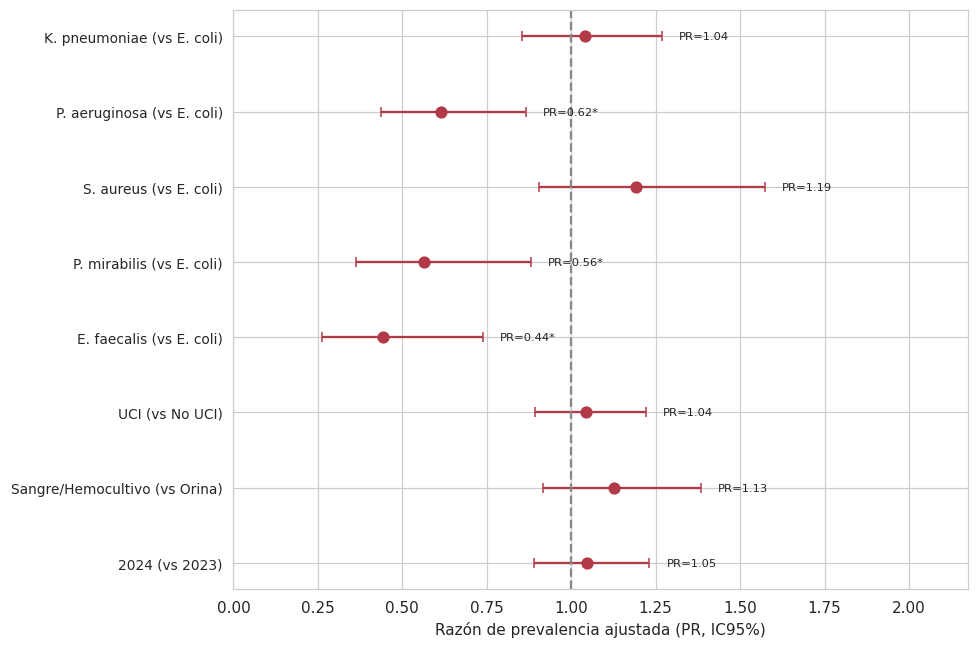

✓ Guardadas: Figura6_forest_MDR.png / .pdf


In [12]:
res_plot = res.iloc[::-1]   # invertir para lectura de arriba a abajo

fig, ax = plt.subplots(figsize=(9, 6))
y = range(len(res_plot))
ax.errorbar(res_plot["PR"], y,
            xerr=[res_plot["PR"] - res_plot["IC95_inf"],
                  res_plot["IC95_sup"] - res_plot["PR"]],
            fmt="o", color="#B23A48", capsize=3, ms=7, lw=1.5)
ax.axvline(1, ls="--", color="#888")   # línea de no efecto
ax.set_yticks(list(y))
ax.set_yticklabels(res_plot.index, fontsize=9)
ax.set_xlabel("Razón de prevalencia ajustada (PR, IC95%)")
for yi, (pr, p) in enumerate(zip(res_plot["PR"], res_plot["p"])):
    marca = "*" if p < 0.05 else ""
    ax.text(res_plot["IC95_sup"].iloc[yi] + 0.05, yi, f"PR={pr:.2f}{marca}",
            va="center", fontsize=7.5)
ax.set_xlim(0, max(res_plot["IC95_sup"]) + 0.6)

plt.tight_layout()
fig.savefig("Figura6_forest_MDR.png", dpi=300, bbox_inches="tight")
fig.savefig("Figura6_forest_MDR.pdf", bbox_inches="tight")
plt.show()
print("✓ Guardadas: Figura6_forest_MDR.png / .pdf")

## 5. Verificación del ajuste

In [13]:
print(f"Método: {metodo}")
print(f"Deviance: {modelo.deviance:.1f}")
print(f"Pseudo-R² (McFadden aprox): {1 - modelo.deviance/modelo.null_deviance:.3f}")
print(f"AIC: {modelo.aic:.1f}")
n_mdr = m["is_mdr"].sum()
n_params = len(modelo.params) - 1
print(f"Eventos MDR: {n_mdr} | parámetros: {n_params} | EPV: {n_mdr/n_params:.1f} "
      f"({'adecuado' if n_mdr/n_params >= 10 else 'ajustado, interpretar con cautela'})")

Método: Log-binomial
Deviance: 1647.9
Pseudo-R² (McFadden aprox): 0.023
AIC: 1665.9
Eventos MDR: 424 | parámetros: 8 | EPV: 53.0 (adecuado)


## 6. Exportar Tabla 5

In [14]:
tabla5_out.reset_index().rename(columns={"index": "Variable"}).to_excel(
    "Tabla5_modelo_MDR.xlsx", index=False)

from google.colab import files
files.download("Tabla5_modelo_MDR.xlsx")
files.download("Figura6_forest_MDR.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Pipeline RAM Magdalena — Bloque 5B: Figura compuesta de co-resistencia por especie (A/B/C/D)

**Entrada:** `df_base_pretratada`.
**Salida:** una sola figura multipanel (2×2) con la matriz de co-resistencia φ de las cuatro especies clave: **A)** *E. coli*, **B)** *K. pneumoniae* (gramnegativos), **C)** *S. epidermidis*, **D)** *S. aureus* (grampositivos). Extiende el Bloque 5 de una especie a cuatro, en formato de figura de revista.

> **Ajuste de umbrales por tamaño de especie:** los grampositivos tienen menos aislamientos (S. epidermidis n=60, S. aureus n=137) que los gramnegativos (E. coli n=650, K. pneumoniae n=282). Por eso los antibióticos aptos se seleccionan con umbrales proporcionales: `min_test=100` para gramnegativos y `min_test=50` para grampositivos. Cada panel usa el panel antibiótico propio de su grupo (β-lactámicos/carbapenémicos en gramnegativos; oxacilina/macrólidos/lincosamidas en grampositivos), como corresponde biológicamente.


## 0. Preparación y funciones

In [15]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = df_base_pretratada.copy()
ANTIBIOTICOS = [c for c in df.columns if c.isupper() and 2 <= len(c) <= 4 and c != "MDR"]
dfb = df[df["tipo_microorg"] != "Hongo"].copy()

def antibioticos_aptos(sub, min_test, min_R):
    return [ab for ab in ANTIBIOTICOS
            if len(sub[ab].dropna()) >= min_test
            and sub[ab].dropna().nunique() > 1
            and (sub[ab].dropna() == "R").sum() >= min_R]

def matriz_phi(sub, cols, min_pairs=30):
    m = sub[cols].apply(lambda c: c.map({"R": 1, "S": 0, "I": 0}))
    res = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols, dtype=float)
    for a, b in itertools.combinations(cols, 2):
        pair = m[[a, b]].dropna()
        n = len(pair)
        c = (pair[a].corr(pair[b])
             if n >= min_pairs and pair[a].nunique() > 1 and pair[b].nunique() > 1
             else np.nan)
        res.loc[a, b] = res.loc[b, a] = c
    return res

## 1. Configuración de las cuatro especies

In [16]:
# (nombre, min_test, min_R, letra_panel)
CONFIG = [
    ("Escherichia coli",            100, 10, "A"),
    ("Klebsiella pneumoniae",       100, 10, "B"),
    ("Staphylococcus epidermidis",   50,  8, "C"),
    ("Staphylococcus aureus",        50,  8, "D"),
]

## 2. Figura 4 compuesta (2×2)

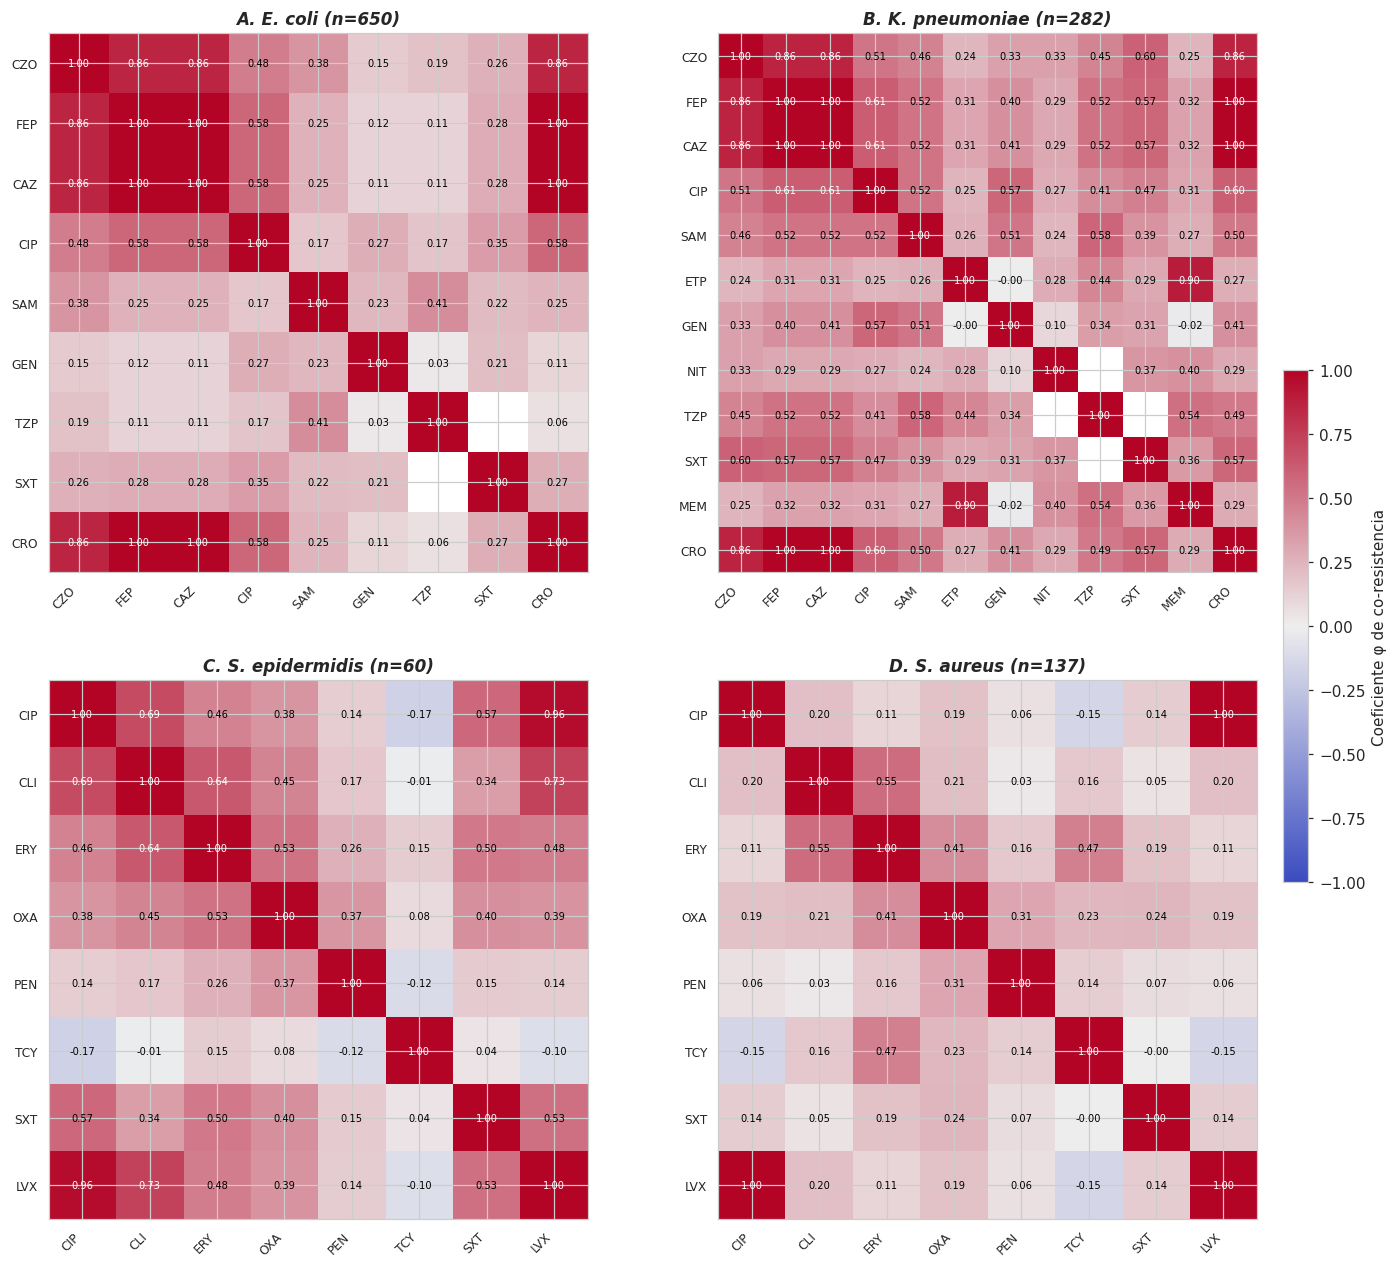

✓ Guardadas: Figura4_coresistencia_multiespecie.png / .pdf


In [19]:
cmap = mcolors.LinearSegmentedColormap.from_list("c", ["#3B4CC0", "#EEEEEE", "#B40426"])

fig, axes = plt.subplots(2, 2, figsize=(15, 14))
axlist = axes.flatten().tolist()   # importante: fijar la lista para el colorbar
im = None

for (esp, mt, mr, letra), ax in zip(CONFIG, axlist):
    sub = dfb[dfb["microorganismo"] == esp]
    cols = antibioticos_aptos(sub, mt, mr)
    corr = matriz_phi(sub, cols)

    im = ax.imshow(corr.values.astype(float), cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(cols)))
    ax.set_yticklabels(cols, fontsize=8)
    for i in range(len(cols)):
        for j in range(len(cols)):
            v = corr.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                        color="white" if abs(v) > 0.6 else "black")
    partes = esp.split()
    nom = f"{partes[0][0]}. {partes[1]}"
    ax.set_title(f"{letra}. {nom} (n={len(sub)})",
                 fontweight="bold", fontstyle="italic", fontsize=11)

fig.subplots_adjust(right=0.9)
cbar = fig.colorbar(im, ax=axlist, fraction=0.02, pad=0.02)
cbar.set_label("Coeficiente φ de co-resistencia", fontsize=10)


fig.savefig("Figura4_coresistencia_multiespecie.png", dpi=300, bbox_inches="tight")
fig.savefig("Figura4_coresistencia_multiespecie.pdf", bbox_inches="tight")
plt.show()
print("✓ Guardadas: Figura4_coresistencia_multiespecie.png / .pdf")

## 3. Extracción de los pares de co-resistencia más fuertes por especie

In [18]:
for esp, mt, mr, letra in CONFIG:
    sub = dfb[dfb["microorganismo"] == esp]
    cols = antibioticos_aptos(sub, mt, mr)
    corr = matriz_phi(sub, cols)
    pares = [(a, b, corr.loc[a, b]) for a, b in itertools.combinations(cols, 2)
             if not np.isnan(corr.loc[a, b])]
    pares.sort(key=lambda x: -x[2])
    print(f"\n{letra}. {esp} ({len(cols)} antibióticos) — top co-resistencias:")
    for a, b, v in pares[:5]:
        print(f"    {a}–{b}: φ = {v:.2f}")


A. Escherichia coli (9 antibióticos) — top co-resistencias:
    FEP–CAZ: φ = 1.00
    FEP–CRO: φ = 1.00
    CAZ–CRO: φ = 1.00
    CZO–FEP: φ = 0.86
    CZO–CRO: φ = 0.86

B. Klebsiella pneumoniae (12 antibióticos) — top co-resistencias:
    FEP–CAZ: φ = 1.00
    FEP–CRO: φ = 1.00
    CAZ–CRO: φ = 1.00
    ETP–MEM: φ = 0.90
    CZO–CAZ: φ = 0.86

C. Staphylococcus epidermidis (8 antibióticos) — top co-resistencias:
    CIP–LVX: φ = 0.96
    CLI–LVX: φ = 0.73
    CIP–CLI: φ = 0.69
    CLI–ERY: φ = 0.64
    CIP–SXT: φ = 0.57

D. Staphylococcus aureus (8 antibióticos) — top co-resistencias:
    CIP–LVX: φ = 1.00
    CLI–ERY: φ = 0.55
    ERY–TCY: φ = 0.47
    ERY–OXA: φ = 0.41
    OXA–PEN: φ = 0.31


## 4. Descargar

In [20]:
from google.colab import files
files.download("Figura4_coresistencia_multiespecie.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

5. Pie de figura sugerido (manuscrito)

> **Figura 4.** Matrices de co-resistencia (coeficiente φ) para las cuatro especies bacterianas principales del HUJMB, 2023–2024. **(A)** *Escherichia coli*, **(B)** *Klebsiella pneumoniae* (gramnegativos), **(C)** *Staphylococcus epidermidis*, **(D)** *Staphylococcus aureus* (grampositivos). El coeficiente φ mide la co-ocurrencia de resistencia entre pares de antibióticos dentro de la misma especie, calculado sobre aislamientos con ambos antibióticos testeados (mínimo 30 pares). Valores próximos a 1 (rojo) indican que las resistencias tienden a presentarse conjuntamente; celdas blancas indican pares con datos insuficientes. Los antibióticos incluidos se seleccionaron por cobertura de testeo y variabilidad dentro de cada especie.
